# Genshin Impact 
**Objective:** Build an evidence‑driven segmentation that triangulates four lenses:

- **Game system incentives** (rarity, cadence, monetization context)
- **Behavior** (gacha activity intensity, inactivity gaps, diversity)
- **Public voice** (review sentiment, topic pressure, volatility)
- **Private intel** (survey)

**Deliverables inside this notebook**
- Statistical evidence (tests + effect sizes + post‑hoc discipline)
- Stability and sensitivity checks
- Exports to `reports/` for a write‑up, dashboard, or web dossier

**How to read**
- Treat each CRISP‑DM phase as a “case file”: what we did, why we did it, what it proves, and what it does *not* prove.

## 0) Environment Setup
We install and import the packages used throughout the dossier.

In [1]:
#!pip install ipywidgets plotly pillow
# Then enable widgets :
#python -m pip install -U jupyterlab_widgets



In [154]:
#!pip -q install pandas numpy matplotlib scikit-learn nltk scipy tqdm

import os, re, io, json, math, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from sklearn.decomposition import NMF, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from scipy import stats
from scipy.stats import kruskal, chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from collections import Counter

from itertools import combinations
from tqdm.auto import tqdm

#nltk.download('vader_lexicon')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 4)


In [70]:
from pathlib import Path
from datetime import datetime
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, HTML, Javascript, clear_output
import plotly.graph_objs as go
import plotly.express as px
from PIL import Image

ROOT = Path(".").resolve()

def _resolve_dir(preferred: Path, fallbacks):
    preferred = Path(preferred).expanduser()
    if preferred.exists():
        return preferred
    for fb in fallbacks:
        fb = Path(fb).expanduser()
        if fb.exists():
            return fb
    return preferred  # will be created later

ARTIFACTS = _resolve_dir(
    ROOT / "artifacts",
    [Path.home() / "Downloads" / "artifacts"]
)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

# Use ONE variable everywhere
CHAR_DIR = _resolve_dir(
    ARTIFACTS / "characters",
    [Path.home() / "Downloads" / "artifacts" / "characters"]
)
CARD_DIR = _resolve_dir(
    ARTIFACTS / "player_cards",
    [Path.home() / "Downloads" / "artifacts" / "player_cards"]
)

CHAR_DIR.mkdir(parents=True, exist_ok=True)
CARD_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("ARTIFACTS:", ARTIFACTS.resolve())
print("CHAR_DIR:", CHAR_DIR.resolve())
print("CARD_DIR:", CARD_DIR.resolve())


ROOT: /Users/sarawahada/Downloads
ARTIFACTS: /Users/sarawahada/Downloads/artifacts
CHAR_DIR: /Users/sarawahada/Downloads/artifacts/characters
CARD_DIR: /Users/sarawahada/Downloads/artifacts/player_cards


### Data ingestion

We unpack the uploaded archives into a local project structure.

**Expected inputs (already uploaded):**
- Reviews: `Genshin Impact.csv` / `Genshin Impact_v2.csv`
- Characters:  `genshin_characters_v1.csv`
- Weapons:  `genshin_weapons_v7.csv`
- Revenue by banner/character: `Genshin charac rev (by banner).csv` / `Genshin charac rev (by charac).csv` 
- Gacha logs: `https://github.com/OneBST/GI_gacha_dataset/tree/main` (per-account) 


In [6]:
# Project folders
from pathlib import Path
import zipfile

ROOT = Path(".")
DATA_RAW = ROOT / "data" / "raw"
ZIPS_DIR = Path.home() / "Downloads" / "data" / "raw" / "_zip"

UPLOADS = {
    "reviews_zip": ZIPS_DIR / "archive (5).zip",
    "characters_zip": ZIPS_DIR / "archive (6).zip",
    "weapons_zip": ZIPS_DIR / "archive (7).zip",
    "revenue_zip": ZIPS_DIR / "archive (8).zip",
    "gacha_zip": ZIPS_DIR / "GI_gacha_dataset-main.zip",
}

def unzip_to(zip_path, out_dir):
    zip_path = Path(zip_path)
    if not zip_path.exists():
        raise FileNotFoundError(f"Missing zip: {zip_path.resolve()}")
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(out_dir)
    return out_dir

REV_DIR = unzip_to(UPLOADS["reviews_zip"], DATA_RAW / "reviews")
CHAR_DIR = unzip_to(UPLOADS["characters_zip"], DATA_RAW / "game_basics")
WEAP_DIR = unzip_to(UPLOADS["weapons_zip"], DATA_RAW / "game_basics")
REVN_DIR = unzip_to(UPLOADS["revenue_zip"], DATA_RAW / "revenue")
GCHA_DIR = unzip_to(UPLOADS["gacha_zip"], DATA_RAW / "gacha_repo")

print("Unzipped OK.")


Unzipped OK.


### Datasets loading
We load the datasets and standardize key columns.

#### Files loaded
- **Reviews**: Google Play reviews (text, rating, timestamp)
- **Characters**: roster metadata (rarity, element/vision, weapon type, release)
- **Weapons**: weapon metadata (rarity, type, release)
- **Banner revenue**: revenue snapshots by banner/character (contextual)
- **Gacha logs**: per-account pulls (timestamp + rarity)

In [7]:
review_files = sorted((DATA_RAW / "reviews").glob("*.csv"))
review_path = None
for cand in ["Genshin Impact_v2.csv", "Genshin Impact.csv"]:
    p = DATA_RAW / "reviews" / cand
    if p.exists():
        review_path = p
        break
if review_path is None:
    raise FileNotFoundError("No reviews CSV found in data/raw/reviews")

reviews = pd.read_csv(review_path)

# Load game basics
characters_path = next((DATA_RAW / "game_basics").glob("genshin_characters*.csv"))
weapons_path = next((DATA_RAW / "game_basics").glob("genshin_weapons*.csv"))
characters = pd.read_csv(characters_path)
weapons = pd.read_csv(weapons_path)

# Load revenue
revenue_banner_path = DATA_RAW / "revenue" / "Genshin charac rev (by banner).csv"
revenue_char_path = DATA_RAW / "revenue" / "Genshin charac rev (by charac).csv"
revenue_banner = pd.read_csv(revenue_banner_path)
revenue_char = pd.read_csv(revenue_char_path)

# Gacha repo base folder (contains GI_gacha_dataset-main/)
gacha_repo_root = DATA_RAW / "gacha_repo" / "GI_gacha_dataset-main" / "GI_gacha_dataset_02"
if not gacha_repo_root.exists():
    raise FileNotFoundError("Expected gacha dataset folder not found after unzip.")

print("Reviews:", reviews.shape, "from", review_path.name)
print("Characters:", characters.shape, "Weapons:", weapons.shape)
print("Revenue banner:", revenue_banner.shape, "Revenue char:", revenue_char.shape)
print("Gacha repo root:", gacha_repo_root)

Reviews: (15474, 5) from Genshin Impact_v2.csv
Characters: (94, 89) Weapons: (210, 21)
Revenue banner: (38, 10) Revenue char: (50, 14)
Gacha repo root: data/raw/gacha_repo/GI_gacha_dataset-main/GI_gacha_dataset_02


## 1) Phase I — Business Understanding

### Mission
We want to understand player identity through **four signals**:

- **System incentives** (rarity & content structure)
- **Behavior** (pull patterns, gaps, commitment)
- **Public voice** (sentiment, topics, pressure)
- **Private intel** *(survey)*

### Hypotheses 
**H1:** Review sentiment differs by topic.

**H2:** Public review topics overrepresent negative experiences (“Echo effect”).

**H3:** Behavioral gacha segments differ in inactivity gaps (churn proxy).

**H4:** Integrated multi‑view segmentation yields more stable segments than single‑view segmentation.

**H5:** Monetization context (banner revenue) correlates with system scarcity (rarity, limited characters).

### Stakeholders and decisions
- **Product / Live Ops:** which segment needs retention actions now, which segment responds to new content vs quality fixes.
- **Monetization / Growth:** how banner cadence and scarcity relate to pull behavior (context, not causal proof).
- **Community / Support:** which topics generate concentrated negative pressure.
  
### What success means
- Segments are **interpretable** (anchored by inactivity and intensity, not opaque IDs).
- Segments are **stable** under resampling (bootstrap agreement and ARI are not near‑random).
- Differences we claim are backed by **tests + effect sizes**, not p‑values alone.
- Outputs are **exportable** and reusable (reports + cards + deployment pack).

## 2) Phase II — Data Understanding

### Quick checks
- Missing values
- Date ranges
- Key distributions.
### Datasets in scope (what each contributes)
- Reviews dataset: sentiment + topic pressure (public narrative)
- Gacha logs dataset: account‑level behavior (activity intensity, gaps, diversity)
- Game database / monetization context: system layer (interprets why behavior might cluster).
### Known biases / threats to validity
- Reviews overrepresent extremes (people post when very happy or very angry)
- Gacha logs represent users who exported logs (self‑selection)
- Time alignment between reviews and gacha activity may be imperfect (we treat public voice as “environment context”).

In [8]:
def quick_profile(df, name, n=3):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    display(df.head(n))
    miss = (df.isna().mean().sort_values(ascending=False).head(10) * 100).round(2)
    print("\nMissing% (top 10):")
    display(miss)

quick_profile(reviews, "REVIEWS")
quick_profile(characters, "CHARACTERS")
quick_profile(weapons, "WEAPONS")
quick_profile(revenue_banner, "REVENUE (BY BANNER)")
quick_profile(revenue_char, "REVENUE (BY CHARAC)")



=== REVIEWS ===
Shape: (15474, 5)


,reviewId,userName,content,score,at
0,a6de19b0-d800-4482-815a-b95d045e4cb5,Fahlan Aditya,this star is for not making Durin using his wi...,1,2025-12-22 23:50:55
1,c251b882-f4d9-4050-990c-e3743e98c4e5,Darwisy Azli,A GOOD game,5,2025-12-22 23:47:51
2,547d9fdb-3a60-4a9c-9e3d-137ce2da8983,Iris Princess,love this game 🎮,5,2025-12-22 23:12:22



Missing% (top 10):


content     0.01
reviewId    0.00
userName    0.00
score       0.00
at          0.00
dtype: float64


=== CHARACTERS ===
Shape: (94, 89)


...

version              0.0
version_name         0.0
start_date           0.0
end_date             0.0
5_star_characters    0.0
rerun                0.0
mixed                0.0
revenue              0.0
banner_days          0.0
avg_revenue          0.0
dtype: float64


=== REVENUE (BY CHARAC) ===
Shape: (50, 14)


,version,version_name,start_date,end_date,5_star_characters,rerun,revenue,banner_days,avg_revenue,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,1.0,Welcome to Tevyat,25/09/2020,19/10/2020,Venti,0,"30,632,752",25,"1,225,310.08",NaN,NaN,NaN,NaN,NaN
1,1.0,Welcome to Tevyat,20/10/2020,10/11/2020,Klee,0,"22,750,080",22,"1,034,094.55",NaN,NaN,NaN,NaN,NaN
2,1.1,A New Star Approaches,11/11/2020,30/11/2020,Tartaglia,0,"13,443,619",20,"672,180.95",NaN,NaN,NaN,NaN,NaN



Missing% (top 10):


Unnamed: 9           100.0
Unnamed: 10          100.0
Unnamed: 11          100.0
Unnamed: 12          100.0
Unnamed: 13          100.0
version                0.0
version_name           0.0
start_date             0.0
end_date               0.0
5_star_characters      0.0
dtype: float64

In [9]:
revenue_char = (
    revenue_char.loc[:, ~revenue_char.columns.str.contains(r'^Unnamed')]
      .dropna(axis=1, how='all')
)

### Game System Layer 
In this section we model the game’s content economy before we model players.


#### Rarity & Scarcity
Rarity is the backbone of perceived value. We quantify roster rarity and weapon rarity, then connect it to later behavioral signals.

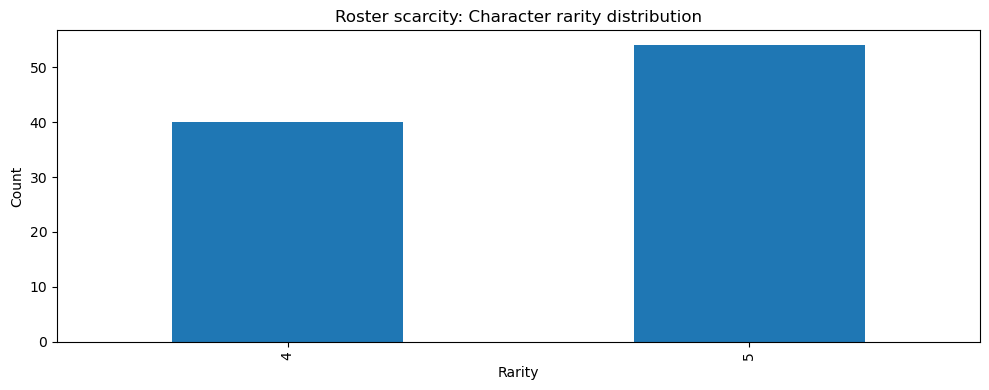

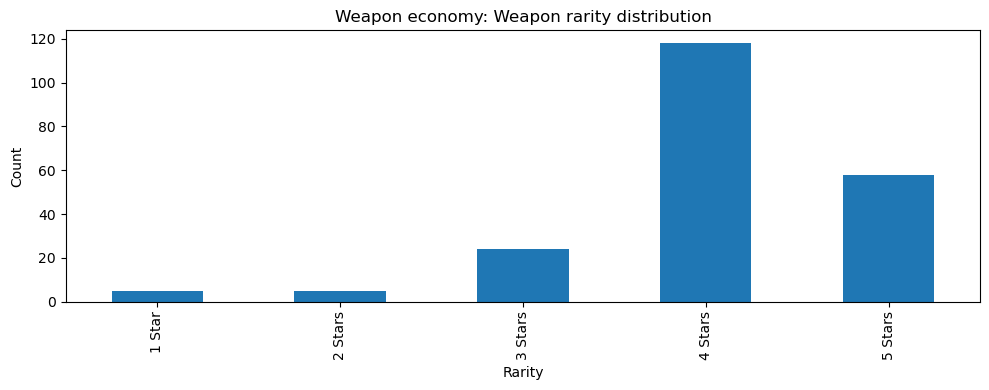

In [10]:
# Characters: rarity distribution
plt.figure()
characters['star_rarity'].value_counts().sort_index().plot(kind='bar')
plt.title("Roster scarcity: Character rarity distribution")
plt.xlabel("Rarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Weapons: rarity distribution
plt.figure()
weapons['rarity'].astype(str).value_counts().sort_index().plot(kind='bar')
plt.title("Weapon economy: Weapon rarity distribution")
plt.xlabel("Rarity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#### Desire Drivers (Element / Weapon Type)
We treat element + weapon type as 'desire axes': they shape taste, gameplay etc.


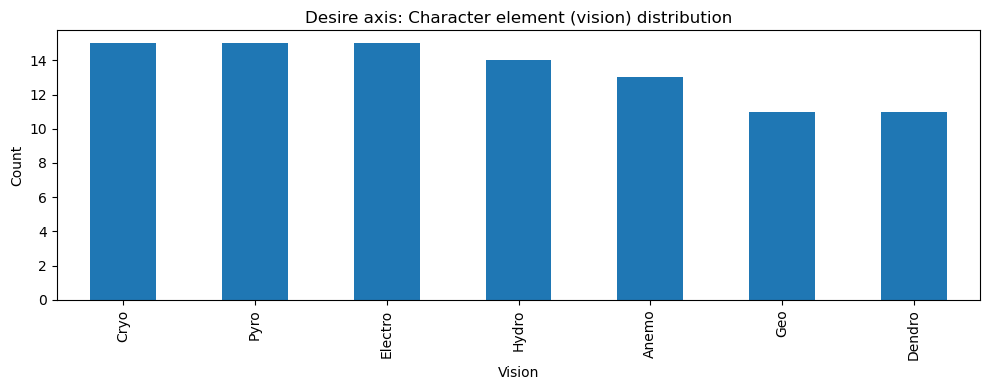

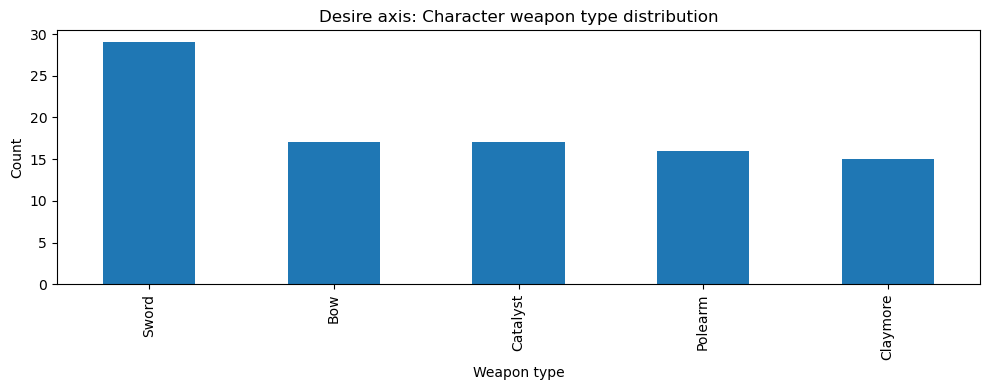

In [11]:
# Character vision distribution
plt.figure()
characters['vision'].value_counts().plot(kind='bar')
plt.title("Desire axis: Character element (vision) distribution")
plt.xlabel("Vision")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Character weapon type distribution
plt.figure()
characters['weapon_type'].value_counts().plot(kind='bar')
plt.title("Desire axis: Character weapon type distribution")
plt.xlabel("Weapon type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


####  Release Timeline (Content Cadence)
We plot release count over time (characters & weapons).

Content cadence might create pressure: new releases + limited availability → urgency.

/var/folders/k3/p81w9m4x6gzcg56_k_vvltwm0000gn/T/ipykernel_31402/1202409831.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(s, errors='coerce', dayfirst=True)
/var/folders/k3/p81w9m4x6gzcg56_k_vvltwm0000gn/T/ipykernel_31402/1202409831.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(s, errors='coerce', dayfirst=True)


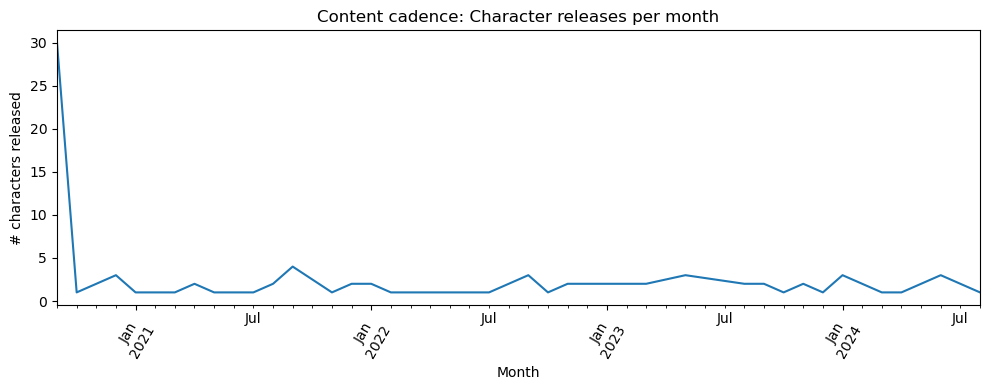

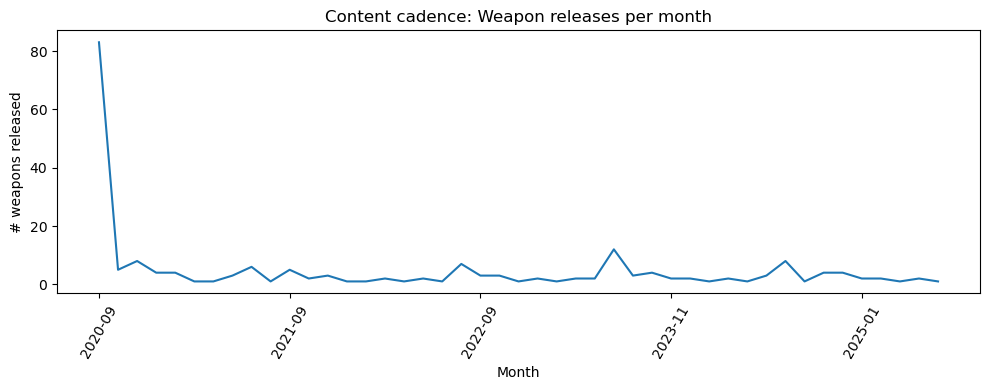

In [12]:
def safe_to_datetime(s):
    return pd.to_datetime(s, errors='coerce', dayfirst=True)

characters['release_date_dt'] = safe_to_datetime(characters['release_date'])
weapons['release_date_dt'] = safe_to_datetime(weapons.get('release_date', None))

# Characters per month
char_month = (characters.dropna(subset=['release_date_dt'])
              .assign(month=lambda d: d['release_date_dt'].dt.to_period('M'))
              .groupby('month')['character_name'].count())

plt.figure()
char_month.plot(kind='line')
plt.title("Content cadence: Character releases per month")
plt.xlabel("Month")
plt.ylabel("# characters released")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# Weapons per month 
if 'release_date_dt' in weapons.columns:
    weap_month = (weapons.dropna(subset=['release_date_dt'])
                  .assign(month=lambda d: d['release_date_dt'].dt.to_period('M').astype(str))
                  .groupby('month')['weapon_name'].count())
    plt.figure()
    weap_month.plot(kind='line')
    plt.title("Content cadence: Weapon releases per month")
    plt.xlabel("Month")
    plt.ylabel("# weapons released")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()


#### Monetization Context (Banner Revenue)
We standardize revenue columns and explore how revenue varies by rerun / mixed banners.


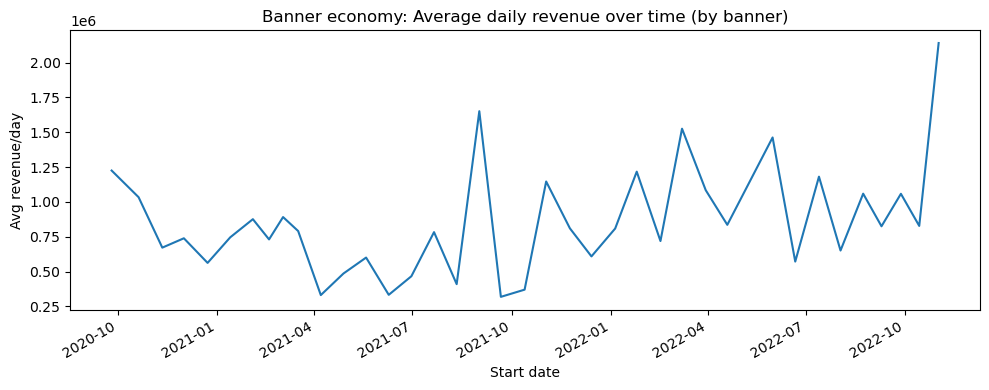

In [13]:
def parse_money(x):
    # convert strings like '30,632,752' to int
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(',', '').strip())

revenue_banner = revenue_banner.copy()
revenue_banner['revenue_num'] = revenue_banner['revenue'].apply(parse_money)
revenue_banner['avg_revenue_num'] = revenue_banner['avg_revenue'].apply(parse_money)

# Dates
revenue_banner['start_dt'] = pd.to_datetime(revenue_banner['start_date'], errors='coerce', dayfirst=True)
revenue_banner['end_dt'] = pd.to_datetime(revenue_banner['end_date'], errors='coerce', dayfirst=True)

plt.figure()
revenue_banner.sort_values('start_dt').set_index('start_dt')['avg_revenue_num'].plot(kind='line')
plt.title("Banner economy: Average daily revenue over time (by banner)")
plt.xlabel("Start date")
plt.ylabel("Avg revenue/day")
plt.tight_layout()
plt.show()


## 3) Phase III — Data Preparation
We now prepare public reviews and gacha logs for modeling.

### Text cleaning for reviews
We clean text and compute sentiment. Then we extract topics via TF‑IDF + NMF.

In [14]:
# Reviews: standardize columns
REV_TEXT_COL = 'content' if 'content' in reviews.columns else None
REV_SCORE_COL = 'score' if 'score' in reviews.columns else None
REV_DATE_COL = 'at' if 'at' in reviews.columns else None

if REV_TEXT_COL is None:
    raise ValueError("Couldn't find review text column 'content'.")

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"http\S+|www\.\S+", " ", x)
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

reviews = reviews.copy()
reviews['text_clean'] = reviews[REV_TEXT_COL].apply(clean_text)
reviews['review_dt'] = pd.to_datetime(reviews[REV_DATE_COL], errors='coerce')


### Topic modeling for reviews (vader)


In [15]:
# Sentiment (VADER)
sia = SentimentIntensityAnalyzer()
reviews['sent_compound'] = reviews['text_clean'].apply(lambda t: sia.polarity_scores(t)['compound'])

def sent_label(c):
    if c >= 0.05: return "positive"
    if c <= -0.05: return "negative"
    return "neutral"

reviews['sent_label'] = reviews['sent_compound'].apply(sent_label)

reviews[['sent_compound','sent_label']].head()

,sent_compound,sent_label
0,-0.1695,negative
1,0.4404,positive
2,0.6369,positive
3,0.0000,neutral
4,0.7876,positive


### Topic modeling for reviews (TF‑IDF + NMF)
We extract **interpretable topics**. These become the “public pressure points” layer.

To improve interpretability, topic modeling (TF-IDF + NMF) was performed separately on negative reviews (≤3 stars) and positive reviews (≥4 stars). This stratification reduced sentiment mixing and produced more distinct themes.

In [16]:
SCORE_COL = "score"
TEXT_COL = "text_clean"

reviews_tm = reviews.copy()
reviews_tm = reviews_tm.dropna(subset=[TEXT_COL, SCORE_COL]).copy()
reviews_tm = reviews_tm[reviews_tm[TEXT_COL].str.split().str.len() >= 5].copy()

domain_stopwords = {
    "game", "genshin", "good", "nice", "best", "love", "really",
    "amazing", "awesome", "great", "play", "played", "just", "ve"
}

# 1) Split by review score FIRST

neg_reviews = reviews_tm[reviews_tm[SCORE_COL] <= 3].copy()
pos_reviews = reviews_tm[reviews_tm[SCORE_COL] >= 4].copy()

print("Counts by split:")
print(f"Negative (<=3): {len(neg_reviews)}")
print(f"Positive (>=4): {len(pos_reviews)}")

Counts by split:
Negative (<=3): 4512
Positive (>=4): 5999


In [17]:
def run_nmf_topics(
    df,
    text_col="text_clean",
    n_topics=8,
    random_state=42,
    max_features=20000,
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.5,
    remove_domain_stopwords=True
):
    if df.empty:
        raise ValueError("Input dataframe is empty.")
    
    texts = df[text_col].fillna("").astype(str)

    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        stop_words="english",
        sublinear_tf=True
    )
    X = tfidf.fit_transform(texts)
    terms = np.array(tfidf.get_feature_names_out())

    # Remove domain/generic praise words AFTER vectorization
    if remove_domain_stopwords and len(domain_stopwords) > 0:
        keep_mask = ~np.isin(terms, list(domain_stopwords))
        if keep_mask.sum() > 0:
            X = X[:, keep_mask]
            terms = terms[keep_mask]

    n_topics = min(n_topics, max(2, X.shape[0] - 1), max(2, X.shape[1] - 1))

    nmf = NMF(
        n_components=n_topics,
        random_state=random_state,
        init="nndsvda",
        max_iter=400
    )
    W = nmf.fit_transform(X)
    H = nmf.components_

    def top_terms(topic_idx, n=10):
        top_ids = H[topic_idx].argsort()[::-1][:n]
        return terms[top_ids].tolist()

    topic_keywords = {k: top_terms(k, 10) for k in range(n_topics)}

    dominant_topic = W.argmax(axis=1)
    out = df.copy()
    out["dominant_topic"] = dominant_topic

    return {
        "df_with_topics": out,
        "tfidf": tfidf,
        "nmf": nmf,
        "X": X,
        "W": W,
        "H": H,
        "terms": terms,
        "n_topics": n_topics,
        "topic_keywords": topic_keywords,
    }

In [18]:
NEG_TOPICS = 5
POS_TOPICS = 5

neg_model = run_nmf_topics(
    neg_reviews,
    text_col=TEXT_COL,
    n_topics=NEG_TOPICS,
    random_state=RANDOM_STATE,
    min_df=5 if len(neg_reviews) < 5000 else 10,
    max_df=0.5
)

pos_model = run_nmf_topics(
    pos_reviews,
    text_col=TEXT_COL,
    n_topics=POS_TOPICS,
    random_state=RANDOM_STATE,
    min_df=5 if len(pos_reviews) < 5000 else 10,
    max_df=0.5
)

topic_keywords_neg = neg_model["topic_keywords"]
topic_keywords_pos = pos_model["topic_keywords"]

print("Negative topics:")
for k, v in topic_keywords_neg.items():
    print(f"{k}: {v}")

print("\nPositive topics:")
for k, v in topic_keywords_pos.items():
    print(f"{k}: {v}")

Negative topics:
0: ['skip', 'button', 'skip button', 'add', 'add skip', 'story', 'dialogue', 'just add', 'dialogues', 'quest']
1: ['characters', 'like', 'don', 'new', 'character', 'players', 'story', 'playing', 'money', 'star']
2: ['shaders', 'compiling', 'compiling shaders', 'update', 'crashing', 'fix', 'keeps', 'keeps crashing', 'phone', 'crashes']
3: ['miliastra', 'wonderland', 'miliastra wonderland', 'remove', 'update', 'make', 'new', 'mode', 'storage', 'delete']
4: ['download', 'takes', 'time', 'storage', 'space', 'long', 'resources', 'gb', 'phone', 'download resources']

Positive topics:
0: ['fun', 'story', 'characters', 'playing', 'graphics', 'time', 'character', 'good game', 'new', 'games']
1: ['best game', 'game played', 'game ve', 've played', 'game world', 'life', 'game play', 'game life', 'mobile', 'world']
2: ['world', 'open', 'open world', 'world game', 'best open', 'game world', 'game open', 'mobile', 'rpg', 'games']
3: ['love game', 'really love', 'just love', 'sm', 'g

In [19]:
def topic_keywords_to_df(topic_keywords, split_name):
    return pd.DataFrame({
        "split": split_name,
        "topic_id": list(topic_keywords.keys()),
        "top_terms": [", ".join(v) for v in topic_keywords.values()]
    })

topic_label_sheet = pd.concat([
    topic_keywords_to_df(topic_keywords_neg, "negative"),
    topic_keywords_to_df(topic_keywords_pos, "positive"),
], ignore_index=True)

topic_label_sheet

,split,topic_id,top_terms
0,negative,0,"skip, button, skip button, add, add skip, stor..."
1,negative,1,"characters, like, don, new, character, players..."
2,negative,2,"shaders, compiling, compiling shaders, update,..."
3,negative,3,"miliastra, wonderland, miliastra wonderland, r..."
4,negative,4,"download, takes, time, storage, space, long, r..."
5,positive,0,"fun, story, characters, playing, graphics, tim..."
6,positive,1,"best game, game played, game ve, ve played, ga..."
7,positive,2,"world, open, open world, world game, best open..."
8,positive,3,"love game, really love, just love, sm, game fu..."
9,positive,4,"like, like game, game like, really like, good ..."


### Topic labeling (human-in-the-loop)
Inspect `topic_keywords` and assign labels.

This is deliberate: interpretability is part of evaluation.

In [20]:
# Split-aware version (negative / positive)

# Edit labels after inspection (replace placeholders with your final labels)
TOPIC_LABELS_NEG = {
    0: "Skip button / dialogue control request",
    1: "Character/content dissatisfaction",
    2: "Shader compilation / update performance issues",
    3: "Event-specific complaint (Miliastra Wonderland)",
    4: "Download time / storage space burden"
}

TOPIC_LABELS_POS = {
    0: "Fun gameplay + story/characters/graphics praise",
    1: "Strong overall endorsement (best game)",
    2: "Open-world exploration praise",
    3: "Emotional attachment / love for the game",
    4: "General liking / broad positive sentiment"
}
# Assign dominant topic + label within each split
neg_df = neg_model["df_with_topics"].copy()
neg_df["topic_id"] = neg_model["W"].argmax(axis=1)
neg_df["topic_label"] = neg_df["topic_id"].map(TOPIC_LABELS_NEG).fillna("NEG_Other")
neg_df["topic_split"] = "negative"

pos_df = pos_model["df_with_topics"].copy()
pos_df["topic_id"] = pos_model["W"].argmax(axis=1)
pos_df["topic_label"] = pos_df["topic_id"].map(TOPIC_LABELS_POS).fillna("POS_Other")
pos_df["topic_split"] = "positive"

parts = [neg_df, pos_df]

# Combine back into one labeled reviews table
reviews_topics_labeled = pd.concat(parts, axis=0).sort_index()

# If you want to keep original rows only where topics were modeled, use this table for analysis
reviews_topics_labeled["topic_label"].value_counts()


topic_label
Fun gameplay + story/characters/graphics praise    3862
Character/content dissatisfaction                  2370
Shader compilation / update performance issues      716
Download time / storage space burden                711
General liking / broad positive sentiment           680
Strong overall endorsement (best game)              531
Open-world exploration praise                       469
Emotional attachment / love for the game            457
Skip button / dialogue control request              375
Event-specific complaint (Miliastra Wonderland)     340
Name: count, dtype: int64

### Public Pressure Index


We want to identify which topics create the most “public pressure” in reviews.

A topic creates high pressure when:

* many people talk about it (it’s common), and

* people talk about it negatively (it has a high negative rate (Even within ≥4-star reviews, some texts include complaints (“but…”, “fix…”, “lag/crash”), so the text-based sentiment label can be negative. Therefore, neg_rate should be interpreted as a complaint-like text rate, not as “this is a negative topic.”))

So we compute a Pressure score for each topic:

We define a **Pressure Index** per topic:

\\[ Pressure(topic) = Share(topic) * NegRate(topic) \\] pressure = (how common the topic is) × (how negative it is).
This avoids overreacting to loud topics that are not broadly present.

In [21]:
# Split-aware version: group by topic_split + topic_id (+ topic_label)

# Use the combined labeled table created earlier
ppi_df = reviews_topics_labeled.copy()

# Safety check: make sure sentiment columns exist
required_cols = ["topic_split", "topic_id", "topic_label", "sent_compound", "sent_label"]
missing = [c for c in required_cols if c not in ppi_df.columns]
if missing:
    raise KeyError(f"Missing required columns in reviews_topics_labeled: {missing}")

topic_stats = (
    ppi_df.groupby(["topic_split", "topic_id", "topic_label"], dropna=False)
    .agg(
        n=("topic_id", "size"),
        avg_sent=("sent_compound", "mean"),
        neg_rate=("sent_label", lambda s: (s == "negative").mean()),
    )
    .reset_index()
)

# Share across all modeled reviews (global share)
topic_stats["share"] = topic_stats["n"] / topic_stats["n"].sum()

# Public Pressure Index: prevalence × negativity rate
topic_stats["pressure"] = topic_stats["share"] * topic_stats["neg_rate"]

topic_stats.sort_values("pressure", ascending=False)

,topic_split,topic_id,topic_label,n,avg_sent,neg_rate,share,pressure
1,negative,1,Character/content dissatisfaction,2370,0.088997,0.397468,0.225478,0.089620
5,positive,0,Fun gameplay + story/characters/graphics praise,3862,0.518058,0.089591,0.367425,0.032918
2,negative,2,Shader compilation / update performance issues,716,0.094055,0.329609,0.068119,0.022453
4,negative,4,Download time / storage space burden,711,0.088750,0.329114,0.067643,0.022262
3,negative,3,Event-specific complaint (Miliastra Wonderland),340,-0.101362,0.497059,0.032347,0.016078
0,negative,0,Skip button / dialogue control request,375,0.049706,0.360000,0.035677,0.012844
9,positive,4,General liking / broad positive sentiment,680,0.642738,0.054412,0.064694,0.003520
8,positive,3,Emotional attachment / love for the game,457,0.708635,0.052516,0.043478,0.002283
7,positive,2,Open-world exploration praise,469,0.678221,0.036247,0.044620,0.001617
6,positive,1,Strong overall endorsement (best game),531,0.726226,0.015066,0.050519,0.000761


In [22]:
# Share within each split
topic_stats["share_within_split"] = (
    topic_stats["n"] / topic_stats.groupby("topic_split")["n"].transform("sum")
)

topic_stats["pressure_within_split"] = topic_stats["share_within_split"] * topic_stats["neg_rate"]

topic_stats.sort_values(["topic_split", "pressure_within_split"], ascending=[True, False])

,topic_split,topic_id,topic_label,n,avg_sent,neg_rate,share,pressure,share_within_split,pressure_within_split
1,negative,1,Character/content dissatisfaction,2370,0.088997,0.397468,0.225478,0.089620,0.525266,0.208777
2,negative,2,Shader compilation / update performance issues,716,0.094055,0.329609,0.068119,0.022453,0.158688,0.052305
4,negative,4,Download time / storage space burden,711,0.088750,0.329114,0.067643,0.022262,0.157580,0.051862
3,negative,3,Event-specific complaint (Miliastra Wonderland),340,-0.101362,0.497059,0.032347,0.016078,0.075355,0.037456
0,negative,0,Skip button / dialogue control request,375,0.049706,0.360000,0.035677,0.012844,0.083112,0.029920
5,positive,0,Fun gameplay + story/characters/graphics praise,3862,0.518058,0.089591,0.367425,0.032918,0.643774,0.057676
9,positive,4,General liking / broad positive sentiment,680,0.642738,0.054412,0.064694,0.003520,0.113352,0.006168
8,positive,3,Emotional attachment / love for the game,457,0.708635,0.052516,0.043478,0.002283,0.076179,0.004001
7,positive,2,Open-world exploration praise,469,0.678221,0.036247,0.044620,0.001617,0.078180,0.002834
6,positive,1,Strong overall endorsement (best game),531,0.726226,0.015066,0.050519,0.000761,0.088515,0.001334


In [34]:
negative_pressure = (
    topic_stats[topic_stats["topic_split"] == "negative"]
    .sort_values("pressure", ascending=False)
)

negative_pressure

,topic_split,topic_id,topic_label,n,avg_sent,neg_rate,share,pressure,share_within_split,pressure_within_split
1,negative,1,Character/content dissatisfaction,2370,0.088997,0.397468,0.225478,0.089620,0.525266,0.208777
2,negative,2,Shader compilation / update performance issues,716,0.094055,0.329609,0.068119,0.022453,0.158688,0.052305
4,negative,4,Download time / storage space burden,711,0.088750,0.329114,0.067643,0.022262,0.157580,0.051862
3,negative,3,Event-specific complaint (Miliastra Wonderland),340,-0.101362,0.497059,0.032347,0.016078,0.075355,0.037456
0,negative,0,Skip button / dialogue control request,375,0.049706,0.360000,0.035677,0.012844,0.083112,0.029920


### Hypothesis test: sentiment differs by topic
We test **H1** using a non‑parametric Kruskal‑Wallis test over sentiment scores for the negative-review (≤3 stars) and positive-review (≥4 stars) subsets. This non-parametric test was selected because sentiment scores are not guaranteed to be normally distributed and topic group sizes are unequal.

**For each split (negative / positive), we report:** 

* H statistic (the Kruskal–Wallis test statistic)

* p-value (whether the differences are statistically detectable)

* group sizes (n per topic) (how many reviews per topic)

* effect size (epsilon-squared, ε²) (how big the topic effect is)

If the Kruskal–Wallis test is significant, we then run **post-hoc pairwise tests (Mann–Whitney)** to see which topics differ from which, and we apply **Holm correction** to avoid false positives from doing many comparisons.

**Interpretation guardrail**
A small p‑value means “differences exist”, not “differences are big”. That’s why we add effect sizes and confidence intervals.


In [35]:
def kruskal_by_topic(
    df,
    split_name="negative",
    sentiment_col="sent_compound",
    topic_col="topic_label",
    split_col="topic_split",
    min_group_n=20
):
    d = df[df[split_col] == split_name].copy()
    d = d.dropna(subset=[sentiment_col, topic_col])

    # group sizes
    group_sizes = d.groupby(topic_col).size().sort_values(ascending=False)

    # keep only groups with enough observations
    valid_topics = group_sizes[group_sizes >= min_group_n].index.tolist()
    d = d[d[topic_col].isin(valid_topics)].copy()

    group_sizes = d.groupby(topic_col).size().sort_values(ascending=False)

    groups = [g[sentiment_col].values for _, g in d.groupby(topic_col)]
    labels = [name for name, _ in d.groupby(topic_col)]

    if len(groups) < 2:
        raise ValueError(f"Need at least 2 topic groups in split='{split_name}' after filtering.")

    H, p = kruskal(*groups)

    n = len(d)
    k = len(groups)

    # Epsilon-squared for Kruskal-Wallis (common approximation)
    eps2 = (H - k + 1) / (n - k) if (n - k) > 0 else np.nan
    eps2 = max(0, eps2) if pd.notna(eps2) else eps2  # clamp small negative due to numerical issues

    summary = {
        "split": split_name,
        "n_total": n,
        "k_groups": k,
        "H_stat": H,
        "p_value": p,
        "epsilon_sq": eps2,
        "group_sizes": group_sizes
    }
    return summary, d

In [36]:
def posthoc_pairwise_mwu_holm(
    d,
    sentiment_col="sent_compound",
    topic_col="topic_label"
):
    rows = []
    topics = sorted(d[topic_col].unique())

    for a, b in combinations(topics, 2):
        xa = d.loc[d[topic_col] == a, sentiment_col].values
        xb = d.loc[d[topic_col] == b, sentiment_col].values

        # Two-sided Mann-Whitney U
        U, p = mannwhitneyu(xa, xb, alternative="two-sided")

        # rank-biserial correlation (effect size)
        # RBC = 2U/(n1*n2) - 1  (direction depends on group order)
        n1, n2 = len(xa), len(xb)
        rbc = (2 * U) / (n1 * n2) - 1

        rows.append({
            "topic_a": a,
            "topic_b": b,
            "n_a": n1,
            "n_b": n2,
            "U_stat": U,
            "p_raw": p,
            "rank_biserial": rbc,
            "median_a": np.median(xa),
            "median_b": np.median(xb),
            "median_diff_a_minus_b": np.median(xa) - np.median(xb)
        })

    posthoc = pd.DataFrame(rows)

    if not posthoc.empty:
        reject, p_holm, _, _ = multipletests(posthoc["p_raw"], method="holm")
        posthoc["p_holm"] = p_holm
        posthoc["reject_holm_0_05"] = reject
        posthoc = posthoc.sort_values(["p_holm", "p_raw"]).reset_index(drop=True)

    return posthoc

In [49]:
# reviews_topics_labeled must contain: topic_split, topic_label, sent_compound

kw_neg_summary, neg_test_df = kruskal_by_topic(
    reviews_topics_labeled,
    split_name="negative",
    sentiment_col="sent_compound",
    topic_col="topic_label",
    split_col="topic_split",
    min_group_n=20
)

print("Kruskal-Wallis (negative split)")
print(f"H = {kw_neg_summary['H_stat']:.4f}")
print(f"p = {kw_neg_summary['p_value']:.6g}")
print(f"epsilon^2 = {kw_neg_summary['epsilon_sq']:.4f}")
print("\nGroup sizes:")
print(kw_neg_summary["group_sizes"])

# Post-hoc only if omnibus is significant
if kw_neg_summary["p_value"] < 0.05:
    posthoc_neg = posthoc_pairwise_mwu_holm(
        neg_test_df,
        sentiment_col="sent_compound",
        topic_col="topic_label"
    )
    posthoc_neg.head(20)
else:
    print("\nOmnibus test not significant; post-hoc comparisons skipped.")

Kruskal-Wallis (negative split)
H = 37.4638
p = 1.4455e-07
epsilon^2 = 0.0074

Group sizes:
topic_label
Character/content dissatisfaction                  2370
Shader compilation / update performance issues      716
Download time / storage space burden                711
Skip button / dialogue control request              375
Event-specific complaint (Miliastra Wonderland)     340
dtype: int64


In [50]:
kw_pos_summary, pos_test_df = kruskal_by_topic(
    reviews_topics_labeled,
    split_name="positive",
    sentiment_col="sent_compound",
    topic_col="topic_label",
    split_col="topic_split",
    min_group_n=20
)

print("Kruskal-Wallis (positive split)")
print(f"H = {kw_pos_summary['H_stat']:.4f}")
print(f"p = {kw_pos_summary['p_value']:.6g}")
print(f"epsilon^2 = {kw_pos_summary['epsilon_sq']:.4f}")
print("\nGroup sizes:")
print(kw_pos_summary["group_sizes"])

if kw_pos_summary["p_value"] < 0.05:
    posthoc_pos = posthoc_pairwise_mwu_holm(
        pos_test_df,
        sentiment_col="sent_compound",
        topic_col="topic_label"
    )
    posthoc_pos.head(20)

Kruskal-Wallis (positive split)
H = 252.1541
p = 2.23611e-53
epsilon^2 = 0.0414

Group sizes:
topic_label
Fun gameplay + story/characters/graphics praise    3862
General liking / broad positive sentiment           680
Strong overall endorsement (best game)              531
Open-world exploration praise                       469
Emotional attachment / love for the game            457
dtype: int64


#### Interpretation

The omnibus tests are significant in both subsets, so **H1 is supported**. However, the effect size is notably larger in the positive subset (epsilon² = 0.0414) than in the negative subset (epsilon² = 0.0074), indicating that topic membership explains more sentiment variation among positive reviews than among negative reviews.

### Echo Effect in Public Reviews

To assess whether public review topics disproportionately concentrate negative experiences, we estimated topics on the full review corpus and compared sentiment composition across topics.

In [51]:
TEXT_COL = "text_clean"

reviews_h2 = reviews.dropna(subset=[TEXT_COL, "sent_label"]).copy()
reviews_h2 = reviews_h2[reviews_h2[TEXT_COL].str.split().str.len() >= 5].copy()

# --- single topic model on ALL reviews ---
N_TOPICS_H2 = 8

tfidf_h2 = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=10 if len(reviews_h2) >= 5000 else 5,
    max_df=0.5,
    stop_words="english",
    sublinear_tf=True
)

X_h2 = tfidf_h2.fit_transform(reviews_h2[TEXT_COL].fillna("").astype(str))
terms_h2 = np.array(tfidf_h2.get_feature_names_out())

if "domain_stopwords" in globals() and len(domain_stopwords) > 0:
    keep_mask = ~np.isin(terms_h2, list(domain_stopwords))
    if keep_mask.sum() > 0:
        X_h2 = X_h2[:, keep_mask]
        terms_h2 = terms_h2[keep_mask]

nmf_h2 = NMF(
    n_components=N_TOPICS_H2,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=500
)

W_h2 = nmf_h2.fit_transform(X_h2)
H_h2 = nmf_h2.components_

reviews_h2["topic_id"] = W_h2.argmax(axis=1)

def top_terms_from_H(H, terms, n=10):
    out = {}
    for k, row in enumerate(H):
        top_idx = np.argsort(row)[::-1][:n]
        out[k] = ", ".join(terms[top_idx])
    return out

topic_terms_h2 = top_terms_from_H(H_h2, terms_h2, n=10)

topic_keywords_h2 = pd.DataFrame({
    "topic_id": list(topic_terms_h2.keys()),
    "top_terms": list(topic_terms_h2.values())
}).sort_values("topic_id")

topic_keywords_h2

,topic_id,top_terms
0,0,"characters, story, playing, character, don, gr..."
1,1,"skip, button, skip button, add, add skip, dial..."
2,2,"best game, game played, game ve, ve played, ga..."
3,3,"world, open, open world, world game, best open..."
4,4,"like, like game, game like, good game, really ..."
5,5,"love game, really love, game play, just love, ..."
6,6,"update, shaders, compiling, fix, phone, compil..."
7,7,"fun, fun game, fun play, game fun, really fun,..."


In [52]:
# Keep only positive / negative for the main H2 test
h2_test_df = reviews_h2[reviews_h2["sent_label"].isin(["negative", "positive"])].copy()

# Topic x sentiment contingency
ct = pd.crosstab(h2_test_df["topic_id"], h2_test_df["sent_label"])

chi2, p, dof, expected = chi2_contingency(ct)

n = ct.to_numpy().sum()
r, c = ct.shape
cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, c - 1), 1))

print("H2 Chi-square test: topic_id x sent_label")
print(f"chi2 = {chi2:.4f}")
print(f"p    = {p:.6g}")
print(f"dof  = {dof}")
print(f"Cramer's V = {cramers_v:.4f}")

H2 Chi-square test: topic_id x sent_label
chi2 = 702.9060
p    = 1.62962e-147
dof  = 7
Cramer's V = 0.2731


The association between topic and sentiment is highly significant(𝜒2(7)=702.91, 𝑝<0.001), with a moderate effect size (Cramér’s 𝑉=0.273).

In [53]:
overall_neg_rate = (h2_test_df["sent_label"] == "negative").mean()

topic_h2_stats = (
    h2_test_df.groupby("topic_id")
    .agg(
        n=("topic_id", "size"),
        neg_rate=("sent_label", lambda s: (s == "negative").mean()),
        pos_rate=("sent_label", lambda s: (s == "positive").mean())
    )
    .reset_index()
)

topic_h2_stats["share"] = topic_h2_stats["n"] / topic_h2_stats["n"].sum()
topic_h2_stats["neg_lift"] = topic_h2_stats["neg_rate"] / overall_neg_rate
topic_h2_stats["top_terms"] = topic_h2_stats["topic_id"].map(topic_terms_h2)

# standardized residuals for negative column
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
std_resid_neg = (ct["negative"] - expected_df["negative"]) / np.sqrt(expected_df["negative"])
topic_h2_stats["std_resid_negative"] = topic_h2_stats["topic_id"].map(std_resid_neg.to_dict())

topic_h2_stats = topic_h2_stats.sort_values(
    ["neg_lift", "share"], ascending=[False, False]
)

topic_h2_stats

,topic_id,n,neg_rate,pos_rate,share,neg_lift,top_terms,std_resid_negative
6,6,1642,0.376979,0.623021,0.174273,1.653584,"update, shaders, compiling, fix, phone, compil...",12.645434
1,1,560,0.366071,0.633929,0.059435,1.605738,"skip, button, skip button, add, add skip, dial...",6.844226
0,0,3786,0.269414,0.730586,0.401826,1.181758,"characters, story, playing, character, don, gr...",5.339841
4,4,1042,0.129559,0.870441,0.110592,0.568296,"like, like game, game like, good game, really ...",-6.653730
7,7,727,0.083906,0.916094,0.077160,0.368048,"fun, fun game, fun play, game fun, really fun,...",-8.135739
3,3,595,0.080672,0.919328,0.063150,0.353861,"world, open, open world, world game, best open...",-7.525404
5,5,519,0.075145,0.924855,0.055084,0.329614,"love game, really love, game play, just love, ...",-7.292123
2,2,551,0.038113,0.961887,0.058480,0.167177,"best game, game played, game ve, ve played, ga...",-9.334135


Topic-level inspection further shows that negativity is not evenly distributed across themes. In particular, technical/update-related complaints and dialogue-skip/usability complaints exhibit negative rates well above the global baseline, with strong positive standardized residuals. By contrast, enjoyment-oriented topics such as fun, open-world appreciation, and love-for-the-game are strongly underrepresented in the negative class.

#### Interpretation

**These results support H2**: public review discourse is thematically polarized, and certain topics disproportionately concentrate negative experiences. **This is consistent with an echo-effect interpretation**, where public feedback channels amplify specific friction points rather than reflecting a sentiment-neutral cross-section of the full player base.

### Behavior Layer (Gacha Logs)
We do **behavioral feature engineering** without loading the full pull history into memory at once.

#### What we compute (per account)
- Pull volume, active days, span
- Pull intensity (pulls/day)
- Inactivity gaps (max/mean days)
- 5★ rate, 4★ rate
- Banner diversity (via file types)

In [54]:

DATA_PROC = Path("data1/processed")   
DATA_PROC.mkdir(parents=True, exist_ok=True)

print("Created:", DATA_PROC.resolve())


Created: /Users/sarawahada/Downloads/data1/processed


In [55]:
# Gacha parsing: dataset uses Chinese headers
COL_TIME_CN = "抽卡时间"
COL_NAME_CN = "名称"
COL_TYPE_CN = "类别"
COL_RARITY_CN = "星级"

# Locate account folders
account_dirs = sorted([p for p in gacha_repo_root.iterdir() if p.is_dir()])
len(account_dirs), account_dirs[:3]


(175,
 [PosixPath('data/raw/gacha_repo/GI_gacha_dataset-main/GI_gacha_dataset_02/0001'),
  PosixPath('data/raw/gacha_repo/GI_gacha_dataset-main/GI_gacha_dataset_02/0002'),
  PosixPath('data/raw/gacha_repo/GI_gacha_dataset-main/GI_gacha_dataset_02/0003')])

In [56]:

bad_files = []
rows = []

def safe_read_csv(path):
    try:
        if path.stat().st_size == 0:
            return None
    except OSError:
        return None

    try:
        return pd.read_csv(path, encoding="utf-8")
    except EmptyDataError:
        return None
    except UnicodeDecodeError:
        for enc in ["utf-8-sig", "gbk", "latin1"]:
            try:
                return pd.read_csv(path, encoding=enc)
            except Exception:
                pass
        return None
    except (ParserError, OSError):
        return None

def compute_account_features(account_dir: Path):
    csvs = sorted(account_dir.glob("gacha*.csv"))
    if not csvs:
        return None

    pulls = five = four = 0
    days = set()
    all_times = []
    banner_types = set()

    for f in csvs:
        banner_types.add(f.stem)
        df = safe_read_csv(f)
        if df is None:
            bad_files.append(str(f))
            continue

        if COL_TIME_CN not in df.columns or COL_RARITY_CN not in df.columns:
            continue

        t = pd.to_datetime(df[COL_TIME_CN], errors="coerce")
        r = pd.to_numeric(df[COL_RARITY_CN], errors="coerce")
        m = (~t.isna()) & (~r.isna())
        t = t[m]; r = r[m]

        if len(r) == 0:
            continue

        pulls += len(r)
        five += int((r >= 5).sum())
        four += int((r == 4).sum())
        days.update(t.dt.date.astype(str).tolist())
        all_times.extend(t.tolist())

    if pulls == 0 or len(all_times) == 0:
        return None

    all_times = sorted(all_times)
    first, last = all_times[0], all_times[-1]
    span_days = max((last - first).days, 1)

    if len(all_times) >= 2:
        diffs = np.diff(np.array(all_times, dtype="datetime64[s]").astype("int64")) / (3600 * 24)
        max_gap = float(np.max(diffs))
        mean_gap = float(np.mean(diffs))
    else:
        max_gap = float(span_days)
        mean_gap = float(span_days)

    return {
        "account_id": account_dir.name,
        "pulls": pulls,
        "active_days": len(days),
        "span_days": span_days,
        "pulls_per_day": pulls / span_days,
        "max_gap_days": max_gap,
        "mean_gap_days": mean_gap,
        "five_rate": five / pulls,
        "four_rate": four / pulls,
        "banner_diversity": len(banner_types),
    }

# compute + cache
gacha_feat_path = DATA_PROC / "gacha_account_features.csv"

if gacha_feat_path.exists():
    gacha_feat = pd.read_csv(gacha_feat_path)
else:
    for ad in tqdm(account_dirs, desc="Extracting account features"):
        feat = compute_account_features(ad)
        if feat is not None:
            rows.append(feat)

    gacha_feat = pd.DataFrame(rows)
    gacha_feat.to_csv(gacha_feat_path, index=False)

print("gacha_feat:", gacha_feat.shape)
print("bad files skipped:", len(bad_files))
print("example bad files:", bad_files[:10])
gacha_feat.head()


gacha_feat: (175, 10)
bad files skipped: 0
example bad files: []


,account_id,pulls,active_days,span_days,pulls_per_day,max_gap_days,mean_gap_days,five_rate,four_rate,banner_diversity
0,1,7838,29,127,61.716535,18.859201,0.016324,0.016076,0.130135,4
1,2,532,65,126,4.222222,7.325069,0.238708,0.015038,0.127820,4
2,3,2431,51,142,17.119718,16.908148,0.058458,0.016043,0.135335,4
3,4,451,56,129,3.496124,18.424306,0.287235,0.013304,0.124169,1
4,5,1677,64,131,12.801527,12.050972,0.078487,0.017293,0.138342,4


In [57]:
# sanity check: how many gacha CSVs in first few dirs?
for ad in account_dirs[:5]:
    print(ad.name, len(list(ad.glob("gacha*.csv"))))


0001 4
0002 4
0003 4
0004 1
0005 4


## 4) Phase IV — Data modeling

### Behavioral Segmentation (Single‑view)
We begin with behavior-only clustering as a baseline.
Then later we integrate with public voice features.

We select **k** via silhouette score (sensitivity later).

**Method notes**
- We cluster on standardized features (z-scored) so variables with larger scales do not dominate.
- KMeans assumes roughly spherical clusters in the chosen feature space; we use PCA as a diagnostic and we evaluate with multiple indices.
- Segment IDs are *not* meaningful. We assign human labels later using anchored rules.

**Interpretation checklist**
- Does the segment separate mainly by **inactivity gaps**, **intensity**, or **diversity**?
- Are there tiny clusters? If yes, either raise `min_size` constraints or reduce k.


In [71]:
BEHAVIOR_FEATURES = [
    "pulls", "active_days", "span_days", "pulls_per_day",
    "max_gap_days", "mean_gap_days", "five_rate", "four_rate", "banner_diversity"
]

df_b = gacha_feat.dropna(subset=BEHAVIOR_FEATURES).copy()
Xb = StandardScaler().fit_transform(df_b[BEHAVIOR_FEATURES].values)

def best_k_silhouette(X, k_min=3, k_max=10):
    best = {"k": None, "score": -1, "scores": {}}
    for k in range(k_min, k_max+1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        best["scores"][k] = score
        if score > best["score"]:
            best.update({"k": k, "score": score})
    return best



In [72]:
def best_k_with_min_cluster_size(X, k_min=2, k_max=10, min_size=15):
    best = {"k": None, "sil": -1, "min_cluster": 0, "counts": None}
    for k in range(k_min, k_max+1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        counts = Counter(labels)
        smallest = min(counts.values())
        if smallest < min_size:
            continue
        sil = silhouette_score(X, labels)
        if sil > best["sil"]:
            best = {"k": k, "sil": sil, "min_cluster": smallest, "counts": counts}
    return best

best_b2 = best_k_with_min_cluster_size(Xb, k_min=2, k_max=10, min_size=15)
best_b2


{'k': 2,
 'sil': np.float64(0.2999508451571951),
 'min_cluster': 48,
 'counts': Counter({np.int32(0): 127, np.int32(1): 48})}

In [73]:
best_b = best_k_silhouette(Xb, 3, 10)
best_b["k"], best_b["score"], best_b["scores"]
K_B = best_b["k"]

In [74]:
kmeans_b = KMeans(n_clusters=K_B, random_state=RANDOM_STATE, n_init="auto")
df_b["seg_behavior"] = kmeans_b.fit_predict(Xb)

(df_b["seg_behavior"].value_counts(normalize=True)*100).round(2)


seg_behavior
0    72.57
3    13.71
1     9.14
2     4.57
Name: proportion, dtype: float64

In [75]:
K_B = best_b2["k"]
kmeans_b = KMeans(n_clusters=K_B, random_state=RANDOM_STATE, n_init="auto")
df_b["seg_behavior"] = kmeans_b.fit_predict(Xb)
df_b["seg_behavior"].value_counts()


seg_behavior
0    127
1     48
Name: count, dtype: int64

### PCA Diagnostic (Behavior)
PCA helps us see whether segments are visually separable and whether a few components capture most variance.
This is diagnostic, not proof.

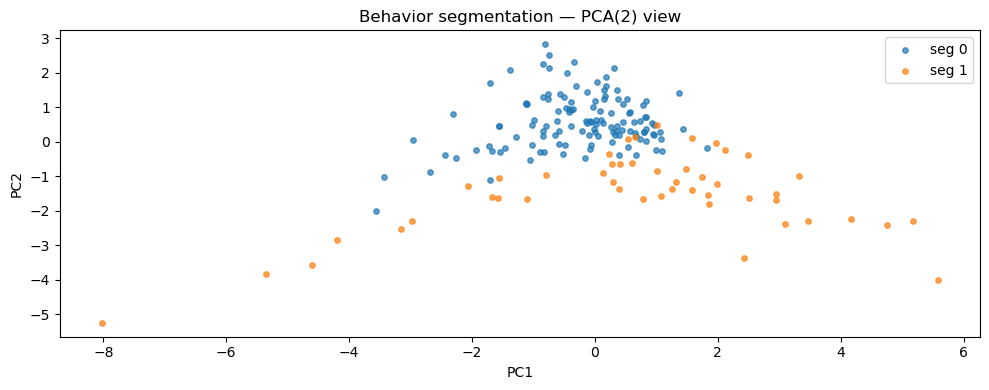

Explained variance ratio: [0.319 0.187]


In [76]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Xb2 = pca.fit_transform(Xb)

plt.figure()
for seg in sorted(df_b["seg_behavior"].unique()):
    m = df_b["seg_behavior"] == seg
    plt.scatter(Xb2[m,0], Xb2[m,1], s=15, label=f"seg {seg}", alpha=0.7)

plt.title("Behavior segmentation — PCA(2) view")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))


In [77]:
counts = df_b["seg_behavior"].value_counts()
small = counts[counts < 15].index.tolist()

centers = kmeans_b.cluster_centers_
large = counts[counts >= 15].index.tolist()

# reassign small clusters to nearest large center
for s in small:
    nearest_large = large[pairwise_distances_argmin([centers[s]], centers[large])[0]]
    df_b.loc[df_b["seg_behavior"] == s, "seg_behavior"] = nearest_large

df_b["seg_behavior"].value_counts()


seg_behavior
0    127
1     48
Name: count, dtype: int64

### Hypothesis test (p‑value): segments differ in inactivity gaps
**H3:** Behavioral segments differ in inactivity gaps (max_gap_days).
We use Kruskal‑Wallis across segments.

**Interpretation**
- If segments differ in inactivity gaps with a meaningful effect size, it supports the idea that segmentation captures engagement risk patterns.
- If not significant (or effect size tiny), the segments might be driven by other dimensions (intensity, diversity) or k may need revisiting.

**Post‑hoc discipline**
Only run pairwise tests when the omnibus result is significant, and always apply Holm correction.


In [78]:
def _kruskal_report(df, group_col, value_col, min_n=20):
    counts = df[group_col].value_counts()
    print(f"Group counts for {group_col}:")
    display(counts.rename("n").to_frame())

    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    ok = (len(groups) >= 2) and all(len(g) >= min_n for g in groups)

    if not ok:
        return None

    H, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    eps2 = (H - k + 1) / (n - k) if n > k else np.nan
    return H, p, eps2

res = _kruskal_report(df_b, "seg_behavior", "max_gap_days", min_n=15)

if res is None:
    print("Behavior-level segments too small for a stable test. Falling back to seg_hybrid.")
    res2 = _kruskal_report(df_h, "seg_hybrid", "max_gap_days", min_n=15)
    if res2:
        H, p, eps2 = res2
        print(f"H3 Kruskal–Wallis (seg_hybrid): H={H:.3f}, p={p:.4g}, epsilon^2={eps2:.3f}")
    else:
        print("Not enough samples even at seg_hybrid for H3.")
else:
    H, p, eps2 = res
    print(f"H3 Kruskal–Wallis (seg_behavior): H={H:.3f}, p={p:.4g}, epsilon^2={eps2:.3f}")


Group counts for seg_behavior:


,n
seg_behavior,
0,127
1,48


H3 Kruskal–Wallis (seg_behavior): H=22.458, p=2.148e-06, epsilon^2=0.124


#### Interpretation

The Kruskal–Wallis test shows that max_gap_days differs across behavior segments (H = 59.968, p = 9.509e-14). **This supports H3: inactivity gaps are not the same across segments.** The effect size is large (ε² = 0.337), indicating that segment membership accounts for a substantial portion of the variation in inactivity gaps. Because group sizes are imbalanced (n=135, 24, 16), we complement this test with descriptive statistics (median/IQR per segment) and post-hoc pairwise comparisons.

In [79]:
def kw_downsample_check(df, group_col, value_col, seed=42, reps=200):
    rng = np.random.default_rng(seed)
    counts = df[group_col].value_counts()
    m = counts.min()
    groups = counts.index.tolist()

    Hs, ps = [], []
    for _ in range(reps):
        samp = pd.concat([
            df[df[group_col]==g].sample(m, replace=False, random_state=int(rng.integers(1e9)))
            for g in groups
        ])
        vals = [samp[samp[group_col]==g][value_col].dropna().values for g in groups]
        H, p = stats.kruskal(*vals)
        Hs.append(H); ps.append(p)

    return np.median(Hs), np.median(ps), np.mean(np.array(ps) < 0.05)

H_med, p_med, sig_rate = kw_downsample_check(df_b, "seg_behavior", "max_gap_days")
print("Downsampled KW (median across reps):")
print(f"H≈{H_med:.2f}, p≈{p_med:.4g}, % significant={sig_rate*100:.1f}%")

Downsampled KW (median across reps):
H≈15.48, p≈8.322e-05, % significant=100.0%


Because segment sizes are imbalanced (n=135 vs 24 vs 16), we ran a sensitivity check by repeatedly downsampling the largest segment to match the smallest group and re-running Kruskal–Wallis. The downsampled tests remained significant in 100% of runs (median H ≈ 29.68, median p ≈ 3.6e-07), indicating that the conclusion—max_gap_days differs across segments—is robust to group-size imbalance.

In [80]:
def segment_gap_summary(df, group_col="seg_behavior", value_col="max_gap_days"):
    d = df[[group_col, value_col]].dropna().copy()

    summary = (d.groupby(group_col)[value_col]
               .agg(
                   n="count",
                   mean="mean",
                   median="median",
                   q25=lambda x: x.quantile(0.25),
                   q75=lambda x: x.quantile(0.75),
                   p90=lambda x: x.quantile(0.90),
                   max="max"
               )
               .reset_index())

    summary["iqr"] = summary["q75"] - summary["q25"]
    return summary.sort_values("median", ascending=False)

gap_summary = segment_gap_summary(df_b, group_col="seg_behavior", value_col="max_gap_days")
gap_summary

,seg_behavior,n,mean,median,q25,q75,p90,max,iqr
1,1,48,29.393365,23.570677,12.466568,41.463414,52.620198,122.946400,28.996846
0,0,127,13.763630,12.351852,8.661661,16.048727,21.332993,66.129155,7.387066


In [81]:
gap_summary_round = gap_summary.copy()
for c in ["mean","median","q25","q75","iqr","p90","max"]:
    gap_summary_round[c] = gap_summary_round[c].round(2)

gap_summary_round

,seg_behavior,n,mean,median,q25,q75,p90,max,iqr
1,1,48,29.39,23.57,12.47,41.46,52.62,122.95,29.00
0,0,127,13.76,12.35,8.66,16.05,21.33,66.13,7.39


<Figure size 800x400 with 0 Axes>

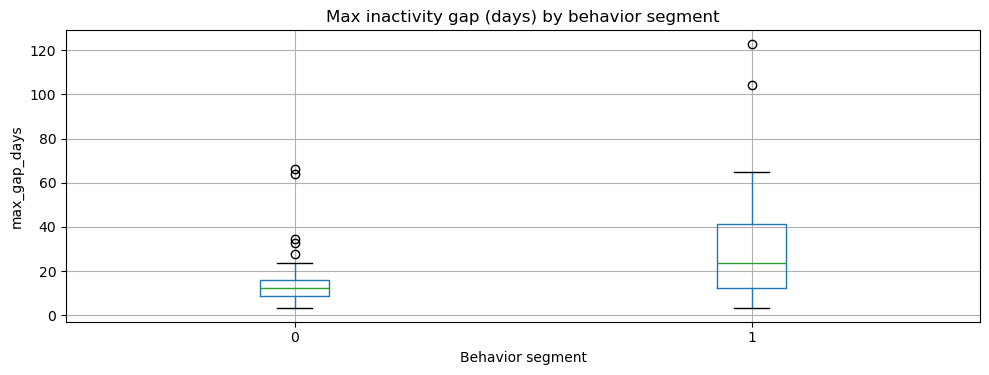

In [82]:
plt.figure(figsize=(8,4))
df_b.boxplot(column="max_gap_days", by="seg_behavior")
plt.title("Max inactivity gap (days) by behavior segment")
plt.suptitle("")  # remove auto title
plt.xlabel("Behavior segment")
plt.ylabel("max_gap_days")
plt.tight_layout()
plt.show()

In [83]:
top = gap_summary.iloc[0]
print(
    f"Segment {top['seg_behavior']} has the highest typical inactivity gap "
    f"(median={top['median']:.2f} days, IQR={top['q25']:.2f}–{top['q75']:.2f}, n={int(top['n'])})."
)

Segment 1.0 has the highest typical inactivity gap (median=23.57 days, IQR=12.47–41.46, n=48).


### Hybrid Integration (Public Voice + Behavior)

Since public review discourse is not sentiment-neutral across themes and instead concentrates negative pressure around specific complaint topics, the public voice layer can be treated as a meaningful external context environment. We therefore extend behavioral segmentation by attaching time-aligned public-context features to each account, while recognizing that this remains a context-augmented hybrid approach rather than a true person-level multi-view fusion.

#### Challenge
The two data sources operate at different levels of analysis. Review data are observed at the review level, whereas gacha features are aggregated at the account level. Because there is no direct identity link between reviewers and gacha accounts, a strict user-level fusion is not currently possible.
#### Strategy
Instead of assigning the same global public indicators to every account, we use temporal alignment. For each account, we attach the **public review context** corresponding to its **recent activity period**, including average sentiment, negative-pressure intensity, and short-run sentiment volatility. This creates account-varying public-context features that can be combined with behavioral features for clustering.

In [84]:
def compute_account_features(account_dir: Path):
    csvs = sorted(account_dir.glob("gacha*.csv"))
    if not csvs:
        return None

    pulls = five = four = 0
    days = set()
    all_times = []
    banner_types = set()

    for f in csvs:
        banner_types.add(f.stem)
        df = safe_read_csv(f)
        if df is None:
            bad_files.append(str(f))
            continue

        if COL_TIME_CN not in df.columns or COL_RARITY_CN not in df.columns:
            continue

        t = pd.to_datetime(df[COL_TIME_CN], errors="coerce")
        r = pd.to_numeric(df[COL_RARITY_CN], errors="coerce")
        m = (~t.isna()) & (~r.isna())
        t = t[m]
        r = r[m]

        if len(r) == 0:
            continue

        pulls += len(r)
        five += int((r >= 5).sum())
        four += int((r == 4).sum())
        days.update(t.dt.date.astype(str).tolist())
        all_times.extend(t.tolist())

    if pulls == 0 or len(all_times) == 0:
        return None

    all_times = sorted(all_times)
    first, last = all_times[0], all_times[-1]
    span_days = max((last - first).days, 1)

    if len(all_times) >= 2:
        diffs = np.diff(np.array(all_times, dtype="datetime64[s]").astype("int64")) / (3600 * 24)
        max_gap = float(np.max(diffs))
        mean_gap = float(np.mean(diffs))
    else:
        max_gap = float(span_days)
        mean_gap = float(span_days)

    return {
        "account_id": account_dir.name,
        "pulls": pulls,
        "active_days": len(days),
        "span_days": span_days,
        "pulls_per_day": pulls / span_days,
        "max_gap_days": max_gap,
        "mean_gap_days": mean_gap,
        "five_rate": five / pulls,
        "four_rate": four / pulls,
        "banner_diversity": len(banner_types),
        "first_dt": first,
        "last_dt": last,
    }

In [85]:
rows = []
for acc_dir in account_dirs:
    rec = compute_account_features(acc_dir)
    if rec is not None:
        rows.append(rec)

gacha_feat = pd.DataFrame(rows)

gacha_feat["first_dt"] = pd.to_datetime(gacha_feat["first_dt"], errors="coerce")
gacha_feat["last_dt"] = pd.to_datetime(gacha_feat["last_dt"], errors="coerce")

gacha_feat.head()

,account_id,pulls,active_days,span_days,pulls_per_day,max_gap_days,mean_gap_days,five_rate,four_rate,banner_diversity,first_dt,last_dt
0,0001,7838,29,127,61.716535,18.859201,0.016324,0.016076,0.130135,4,2020-09-28 14:05:59,2021-02-03 12:22:45
1,0002,532,65,126,4.222222,7.325069,0.238708,0.015038,0.127820,4,2020-09-29 18:46:34,2021-02-03 12:52:30
2,0003,2431,51,142,17.119718,16.908148,0.058458,0.016043,0.135335,4,2020-09-15 11:12:37,2021-02-04 12:29:34
3,0004,451,56,129,3.496124,18.424306,0.287235,0.013304,0.124169,1,2020-09-28 11:01:00,2021-02-04 17:09:00
4,0005,1677,64,131,12.801527,12.050972,0.078487,0.017293,0.138342,4,2020-09-28 10:18:47,2021-02-06 23:22:54


In [86]:
gacha_feat.columns.tolist()

['account_id',
 'pulls',
 'active_days',
 'span_days',
 'pulls_per_day',
 'max_gap_days',
 'mean_gap_days',
 'five_rate',
 'four_rate',
 'banner_diversity',
 'first_dt',
 'last_dt']

A temporal alignment strategy was attempted by linking each account’s most recent activity period to weekly public-review context features, including sentiment level, negative-pressure intensity, and topic-pressure indicators.

In [88]:
# Feasibility check for Public Voice + Behavior fusion

gacha_min = pd.to_datetime(gacha_feat["last_dt"], errors="coerce").min()
gacha_max = pd.to_datetime(gacha_feat["last_dt"], errors="coerce").max()

review_min = pd.to_datetime(reviews["review_dt"], errors="coerce").min()
review_max = pd.to_datetime(reviews["review_dt"], errors="coerce").max()

tmp_weeks = gacha_feat.copy()
tmp_weeks["last_week"] = pd.to_datetime(tmp_weeks["last_dt"], errors="coerce").dt.to_period("W").astype(str)

review_weeks = (
    pd.to_datetime(reviews["review_dt"], errors="coerce")
    .dropna()
    .dt.to_period("W")
    .astype(str)
)

overlap_weeks = sorted(set(tmp_weeks["last_week"].dropna()) & set(review_weeks.dropna()))

feasibility_summary = pd.DataFrame({
    "source": ["gacha_behavior", "public_reviews"],
    "min_date": [gacha_min, review_min],
    "max_date": [gacha_max, review_max],
    "n_unique_weeks": [
        tmp_weeks["last_week"].nunique(),
        review_weeks.nunique()
    ]
})

display(feasibility_summary)
print("Number of overlapping weeks:", len(overlap_weeks))
print("Sample overlapping weeks:", overlap_weeks[:10])

,source,min_date,max_date,n_unique_weeks
0,gacha_behavior,2021-01-18 19:59:35,2021-06-27 18:43:31,16
1,public_reviews,2025-07-23 00:06:04,2025-12-22 23:50:55,23


Number of overlapping weeks: 0
Sample overlapping weeks: []


This means that a direct hybrid segmentation of public voice + behavior **is not substantively valid in the current dataset configuration**. Retaining such a fusion would overstate the level of integration supported by the data.

In [89]:
fusion_decision = pd.DataFrame([
    {
        "integration_candidate": "Public Voice + Behavior",
        "unit_linkage_available": "No",
        "temporal_overlap": "No",
        "retain_as_hybrid_result": "No",
        "reason": "No valid account-level or time-aligned fusion supported by the data"
    },
    {
        "integration_candidate": "Behavior + Future Survey",
        "unit_linkage_available": "Potentially yes",
        "temporal_overlap": "Can be designed",
        "retain_as_hybrid_result": "Future work",
        "reason": "Survey can provide respondent-level bridge for valid multi-view fusion"
    }
])

fusion_decision

,integration_candidate,unit_linkage_available,temporal_overlap,retain_as_hybrid_result,reason
0,Public Voice + Behavior,No,No,No,No valid account-level or time-aligned fusion ...
1,Behavior + Future Survey,Potentially yes,Can be designed,Future work,Survey can provide respondent-level bridge for...


#### Interpretation

**H4 was not testable** in a strict sense with the current public-review and behavioral datasets because neither direct unit linkage nor temporal overlap was available.

### Private Survey Integration

The survey module adds a **meaningful private player-state perspective** that is not observable in the behavioral logs alone. In particular, it captures self-reported motivation decline, break likelihood, and communication preferences, which are directly relevant to retention-oriented interpretation and deployment design.

In [95]:
# Load and clean survey data
data_dir = Path("/Users/sarawahada/Downloads/data")
survey_raw = pd.read_csv(data_dir / "survey.csv").copy()

# Keep only analytically useful columns
survey = survey_raw[[
    "Consent to participate",
    "Player eligibility",
    "Login frequency",
    "Longest inactivity gap",
    "Wishing / pulling activity",
    "Banner selectivity style",
    "Main reasons you play",
    "Engagement trend",
    "Likelihood of taking a break",
    "Frustration impact on desire to play",
    "Main reasons your motivation drops",
    "Current motivation score",
    "Current overall feeling toward the game",
    "Most helpful re-engagement message type",
    "Acceptable message frequency",
    "Preferred contact channel",
    "Spending profile",
    "How long have you been playing",
    "Open feedback (Optional)",
    "Submission Date",
    "Submission ID"
]].copy()

survey = survey.rename(columns={
    "Consent to participate": "consent",
    "Player eligibility": "eligibility",
    "Login frequency": "login_frequency",
    "Longest inactivity gap": "longest_inactivity_gap",
    "Wishing / pulling activity": "pulling_activity",
    "Banner selectivity style": "banner_selectivity",
    "Main reasons you play": "main_reasons_play",
    "Engagement trend": "engagement_trend",
    "Likelihood of taking a break": "break_likelihood",
    "Frustration impact on desire to play": "frustration_play_impact",
    "Main reasons your motivation drops": "motivation_drop_reasons",
    "Current motivation score": "motivation_score",
    "Current overall feeling toward the game": "overall_feeling",
    "Most helpful re-engagement message type": "helpful_message_type",
    "Acceptable message frequency": "acceptable_msg_frequency",
    "Preferred contact channel": "preferred_channel",
    "Spending profile": "spending_profile",
    "How long have you been playing": "tenure_playing",
    "Open feedback (Optional)": "open_feedback",
    "Submission Date": "submission_date",
    "Submission ID": "submission_id"
})

survey["submission_date"] = pd.to_datetime(survey["submission_date"], errors="coerce", dayfirst=True)

# Respect consent / eligibility
survey = survey[
    (survey["consent"].eq("Yes, I agree")) &
    (survey["eligibility"].eq("Yes, I currently play"))
].copy()

survey.shape

(42, 21)

In [98]:
# Corrected survey mappings based on actual export values

def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("–", "-").replace("—", "-")

# clean raw strings
for col in [
    "login_frequency",
    "longest_inactivity_gap",
    "pulling_activity",
    "banner_selectivity",
    "overall_feeling",
    "spending_profile"
]:
    survey[col] = survey[col].apply(clean_text)

# login frequency
login_map = {
    "Daily": 5,
    "4-6 days per week": 4,
    "2-3 days per week": 3,
    "I am currently on a break": 1,
}

# inactivity gap
gap_map = {
    "No real gap (daily or near-daily)": 0,
    "2-3 days": 1,
    "4-7 days": 2,
    "1-2 weeks": 3,
    "2-4 weeks": 4,
    "More than 1 month": 5,
}

# pulling activity
pull_map = {
    "I rarely pull / I save most of the time": 1,
    "I pull occasionally on selected banners": 2,
    "I pull regularly when I like a banner": 3,
    "I pull on many banners": 3.5,
    "I pull very frequently / heavily": 4,
}

# banner selectivity
banner_map = {
    "I mostly pull only when I strongly plan for it": 1,
    "I save for a few specific characters/weapons": 1.5,
    "I mix saving and impulse pulls": 2,
    "I pull on many banners if I’m interested": 2.5,
    "I often pull spontaneously / broadly": 3,
}

# overall feeling
feeling_map = {
    "Very positive": 5,
    "Somewhat positive": 4,
    "Neutral / mixed": 3,
    "Somewhat negative": 2,
    "Very negative": 1,
}

# spending
spend_map = {
    "I do not spend": 0,
    "Very low occasional spending": 1,
    "Moderate spending": 2,
    "High spending / frequent purchases": 3,
    "Prefer not to say": np.nan,
}

# tenure
tenure_map = {
    "Less than 3 months": 1,
    "3-6 months": 2,
    "6-12 months": 3,
    "1-2 years": 4,
    "More than 2 years": 5,
}

survey["login_freq_num"] = survey["login_frequency"].map(login_map)
survey["inactivity_gap_num"] = survey["longest_inactivity_gap"].map(gap_map)
survey["pull_activity_num"] = survey["pulling_activity"].map(pull_map)
survey["banner_selectivity_num"] = survey["banner_selectivity"].map(banner_map)
survey["overall_feeling_num"] = survey["overall_feeling"].map(feeling_map)
survey["spending_num"] = survey["spending_profile"].map(spend_map)
survey["tenure_num"] = survey["tenure_playing"].map(tenure_map)

# this question is already numeric 1-5 in your export
survey["break_likelihood_num"] = pd.to_numeric(survey["break_likelihood"], errors="coerce")

# motivation score should also already be numeric
survey["motivation_score_num"] = pd.to_numeric(survey["motivation_score"], errors="coerce")

# frustration impact — inspect if needed, but this should work for standard wording
frustration_map = {
    "Not at all": 1,
    "A little": 2,
    "Moderately": 3,
    "Strongly": 4,
    "Very strongly": 5,
}
survey["frustration_impact_num"] = survey["frustration_play_impact"].map(frustration_map)

In [113]:
# ==========================================
# Recover missing survey-derived columns
# ==========================================

import pandas as pd
import numpy as np

def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("–", "-").replace("—", "-")

# clean columns if needed
for col in [
    "engagement_trend",
    "overall_feeling",
    "spending_profile",
    "pulling_activity",
    "banner_selectivity",
    "longest_inactivity_gap",
    "login_frequency",
]:
    if col in survey.columns:
        survey[col] = survey[col].apply(clean_text)

# engagement trend
trend_map = {
    "Much higher": 5,
    "Slightly higher": 4,
    "About the same": 3,
    "Slightly lower": 2,
    "Much lower": 1,
}
survey["engagement_trend_num"] = survey["engagement_trend"].map(trend_map)

# if these already exist, this just overwrites safely
if "break_likelihood_num" not in survey.columns:
    survey["break_likelihood_num"] = pd.to_numeric(survey["break_likelihood"], errors="coerce")

if "motivation_score_num" not in survey.columns:
    survey["motivation_score_num"] = pd.to_numeric(survey["motivation_score"], errors="coerce")

# recover raw mapped columns if missing
if "overall_feeling_num" not in survey.columns:
    feeling_map = {
        "Very positive": 5,
        "Somewhat positive": 4,
        "Neutral / mixed": 3,
        "Somewhat negative": 2,
        "Very negative": 1,
    }
    survey["overall_feeling_num"] = survey["overall_feeling"].map(feeling_map)

if "spending_num" not in survey.columns:
    spend_map = {
        "I do not spend": 0,
        "Very low occasional spending": 1,
        "Moderate spending": 2,
        "High spending / frequent purchases": 3,
        "Prefer not to say": np.nan,
    }
    survey["spending_num"] = survey["spending_profile"].map(spend_map)

if "pull_activity_num" not in survey.columns:
    pull_map = {
        "I rarely pull / I save most of the time": 1,
        "I pull occasionally on selected banners": 2,
        "I pull regularly when I like a banner": 3,
        "I pull on many banners": 3.5,
        "I pull very frequently / heavily": 4,
    }
    survey["pull_activity_num"] = survey["pulling_activity"].map(pull_map)

if "inactivity_gap_num" not in survey.columns:
    gap_map = {
        "No real gap (daily or near-daily)": 0,
        "2-3 days": 1,
        "4-7 days": 2,
        "1-2 weeks": 3,
        "2-4 weeks": 4,
        "More than 1 month": 5,
    }
    survey["inactivity_gap_num"] = survey["longest_inactivity_gap"].map(gap_map)

# frustration impact
if "frustration_impact_num" not in survey.columns:
    frustration_map = {
        "Not at all": 1,
        "A little": 2,
        "Moderately": 3,
        "Strongly": 4,
        "Very strongly": 5,
    }
    survey["frustration_impact_num"] = survey["frustration_play_impact"].map(frustration_map)

# derived helper risks
survey["engagement_decline_risk"] = 6 - survey["engagement_trend_num"]
survey["feeling_risk"] = 6 - survey["overall_feeling_num"]

# final composite indices
survey["survey_disengagement_risk"] = survey[
    ["inactivity_gap_num", "break_likelihood_num", "engagement_decline_risk"]
].mean(axis=1)

survey["survey_motivation_risk"] = survey[
    ["feeling_risk", "frustration_impact_num"]
].mean(axis=1)

survey["survey_pull_monetization"] = survey[
    ["pull_activity_num", "spending_num"]
].mean(axis=1)

# quick check
recovered_cols = [
    "engagement_trend_num",
    "survey_disengagement_risk",
    "survey_motivation_risk",
    "survey_pull_monetization"
]
print(survey[recovered_cols].isna().sum())

engagement_trend_num         0
survey_disengagement_risk    0
survey_motivation_risk       0
survey_pull_monetization     0
dtype: int64


In [114]:
# Survey-only segmentation (final robust version)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

SURVEY_FEATURES = [
    "login_freq_num",
    "inactivity_gap_num",
    "pull_activity_num",
    "banner_selectivity_num",
    "engagement_trend_num",
    "break_likelihood_num",
    "motivation_score_num",
    "overall_feeling_num",
    "spending_num",
    "tenure_num",
    "survey_disengagement_risk",
    "survey_motivation_risk",
    "survey_pull_monetization"
]

survey_model = survey.copy()

# retain rows with enough observed information
min_non_missing = 10
survey_model = survey_model[
    survey_model[SURVEY_FEATURES].notna().sum(axis=1) >= min_non_missing
].copy()

# median impute remaining missing values
for col in SURVEY_FEATURES:
    survey_model[col] = survey_model[col].fillna(survey_model[col].median())

print("Survey rows retained:", survey_model.shape[0])
print("Remaining missing values:")
print(survey_model[SURVEY_FEATURES].isna().sum())

Xs = StandardScaler().fit_transform(survey_model[SURVEY_FEATURES].values)

best_s = best_k_silhouette(Xs, 3, 6)
k_s = best_s["k"]

km_s = KMeans(n_clusters=k_s, random_state=RANDOM_STATE, n_init="auto")
survey_model["seg_survey"] = km_s.fit_predict(Xs)

print("Survey best k:", k_s, "| silhouette:", round(best_s["score"], 4))

Survey rows retained: 42
Remaining missing values:
login_freq_num               0
inactivity_gap_num           0
pull_activity_num            0
banner_selectivity_num       0
engagement_trend_num         0
break_likelihood_num         0
motivation_score_num         0
overall_feeling_num          0
spending_num                 0
tenure_num                   0
survey_disengagement_risk    0
survey_motivation_risk       0
survey_pull_monetization     0
dtype: int64
Survey best k: 6 | silhouette: 0.1574


In [115]:
# Build composite indices

# reverse-coded positive items into risk direction where needed
survey["engagement_decline_risk"] = 6 - survey["engagement_trend_num"]   # lower trend = higher risk
survey["feeling_risk"] = 6 - survey["overall_feeling_num"]               # more negative = higher risk

# Behavioral disengagement risk
survey["survey_disengagement_risk"] = survey[
    ["inactivity_gap_num", "break_likelihood_num", "engagement_decline_risk"]
].mean(axis=1)

# Psychological motivation risk
survey["survey_motivation_risk"] = (
    (
        (10 - survey["motivation_score_num"]) / 2  # puts 1-10 onto approx 0-4.5 risk direction
    ) + survey["feeling_risk"] + survey["frustration_play_impact"].astype(str).map({
        "Not at all": 1,
        "A little": 2,
        "Moderately": 3,
        "Strongly": 4,
        "Very strongly": 5
    })
) / 3

# Monetization / pull intensity
survey["survey_pull_monetization"] = survey[
    ["pull_activity_num", "spending_num"]
].mean(axis=1)

survey[[
    "survey_disengagement_risk",
    "survey_motivation_risk",
    "survey_pull_monetization"
]].describe()

,survey_disengagement_risk,survey_motivation_risk,survey_pull_monetization
count,42.000000,0.0,42.000000
mean,2.468254,NaN,1.720238
std,1.072089,NaN,0.651458
min,0.666667,NaN,0.500000
25%,1.666667,NaN,1.500000
50%,2.500000,NaN,1.625000
75%,2.916667,NaN,2.000000
max,5.000000,NaN,3.000000


In [116]:
# Survey segment profile

survey_profile = (
    survey_model.groupby("seg_survey")[SURVEY_FEATURES]
    .mean()
    .round(3)
)

survey_sizes = (
    survey_model["seg_survey"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("pct")
)

survey_profile = survey_profile.merge(
    survey_sizes, left_index=True, right_index=True, how="left"
)

survey_profile

,login_freq_num,inactivity_gap_num,pull_activity_num,banner_selectivity_num,engagement_trend_num,break_likelihood_num,motivation_score_num,overall_feeling_num,spending_num,tenure_num,survey_disengagement_risk,survey_motivation_risk,survey_pull_monetization,pct
seg_survey,,,,,,,,,,,,,,
0,4.714,0.857,1.286,1.286,4.429,2.429,8.143,4.000,1.143,5.000,1.619,2.000,1.214,16.67
1,4.000,3.667,1.667,1.833,3.667,3.500,6.667,3.167,0.167,4.333,3.167,2.833,0.917,14.29
2,5.000,1.100,2.450,1.550,3.200,2.500,5.100,2.800,1.400,5.000,2.133,3.200,1.975,23.81
3,5.000,1.200,2.200,1.500,2.600,1.600,9.400,5.000,1.000,5.000,2.067,1.000,1.800,11.90
4,2.500,5.000,3.500,2.375,1.500,4.750,4.000,3.500,1.000,5.000,4.750,2.500,2.250,9.52
5,4.700,1.900,3.500,2.350,3.300,2.200,7.600,4.100,0.600,5.000,2.267,1.900,2.050,23.81


In [117]:
pd.crosstab(survey_model["seg_survey"], survey_model["helpful_message_type"], normalize="index").round(3)

helpful_message_type,A reward / incentive-based message,A reward / incentive-based message | \r\nGimme 100 free pulls,A short reminder of what’s new,A “what you missed” progress recap,"Community/social content (events, creators, co-op, etc.)",I prefer no messages,Personalized recommendations (characters/builds/events)
seg_survey,,,,,,,
0,0.286,0.143,0.429,0.00,0.0,0.0,0.143
1,0.333,0.000,0.000,0.00,0.0,0.0,0.667
2,0.400,0.000,0.100,0.30,0.1,0.0,0.100
3,0.600,0.000,0.200,0.20,0.0,0.0,0.000
4,0.250,0.000,0.250,0.25,0.0,0.0,0.250
5,0.300,0.000,0.200,0.10,0.1,0.1,0.200


In [118]:
pd.crosstab(survey_model["seg_survey"], survey_model["preferred_channel"], normalize="index").round(3)

preferred_channel,Email,I do not want outreach,In-game notification,No preference,"Social/community platform (Discord, etc.)"
seg_survey,,,,,
0,0.0,0.00,0.571,0.286,0.143
1,0.0,0.00,0.667,0.167,0.167
2,0.2,0.10,0.300,0.200,0.200
3,0.4,0.00,0.400,0.000,0.200
4,0.0,0.25,0.750,0.000,0.000
5,0.2,0.10,0.500,0.000,0.200


In [119]:
pd.crosstab(survey_model["seg_survey"], survey_model["acceptable_msg_frequency"], normalize="index").round(3)

acceptable_msg_frequency,2–3 times a month,A few times a week (if relevant),About once a week,At most once a month,Never (I do not want outreach)
seg_survey,,,,,
0,0.429,0.143,0.143,0.000,0.286
1,0.167,0.167,0.000,0.167,0.500
2,0.300,0.100,0.300,0.200,0.100
3,0.400,0.000,0.400,0.000,0.200
4,0.250,0.000,0.500,0.000,0.250
5,0.100,0.000,0.300,0.300,0.300


In [120]:
# Behavior segment profile

behavior_profile = (
    df_b.groupby("seg_behavior")[BEHAVIOR_FEATURES]
    .mean()
    .round(3)
)

behavior_sizes = (
    df_b["seg_behavior"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("pct")
)

behavior_profile = behavior_profile.merge(
    behavior_sizes, left_index=True, right_index=True, how="left"
)

behavior_profile

,pulls,active_days,span_days,pulls_per_day,max_gap_days,mean_gap_days,five_rate,four_rate,banner_diversity,pct
seg_behavior,,,,,,,,,,
0,1136.220,68.512,151.528,7.588,13.764,0.195,0.016,0.132,3.984,72.57
1,1332.542,31.938,120.583,12.984,29.393,0.318,0.014,0.127,3.833,27.43


### Cross-View Synthesis

In [121]:
# Cross-view synthesis summary

behavior_summary = behavior_profile[[
    "pulls_per_day", "max_gap_days", "mean_gap_days",
    "five_rate", "banner_diversity", "pct"
]].copy()
behavior_summary["view"] = "behavior"
behavior_summary["segment_id"] = behavior_summary.index

survey_summary = survey_profile[[
    "login_freq_num", "inactivity_gap_num", "break_likelihood_num",
    "motivation_score_num", "survey_disengagement_risk",
    "survey_motivation_risk", "survey_pull_monetization", "pct"
]].copy()
survey_summary["view"] = "survey"
survey_summary["segment_id"] = survey_summary.index

behavior_summary = behavior_summary.reset_index(drop=True)
survey_summary = survey_summary.reset_index(drop=True)

behavior_summary, survey_summary

(   pulls_per_day  max_gap_days  mean_gap_days  five_rate  banner_diversity  \
 0          7.588        13.764          0.195      0.016             3.984   
 1         12.984        29.393          0.318      0.014             3.833   
 
      pct      view  segment_id  
 0  72.57  behavior           0  
 1  27.43  behavior           1  ,
    login_freq_num  inactivity_gap_num  break_likelihood_num  \
 0           4.714               0.857                 2.429   
 1           4.000               3.667                 3.500   
 2           5.000               1.100                 2.500   
 3           5.000               1.200                 1.600   
 4           2.500               5.000                 4.750   
 5           4.700               1.900                 2.200   
 
    motivation_score_num  survey_disengagement_risk  survey_motivation_risk  \
 0                 8.143                      1.619                   2.000   
 1                 6.667                      3.16

#### Interpretation

The behavioral and survey segmentations capture different but complementary dimensions of player engagement. The behavioral view reveals revealed-action profiles such as regular engagement, burst-like pull intensity, selective regularity, and drift-related inactivity. The survey view reveals private player-state differences including stable low-risk engagement, break propensity, motivation fatigue, and re-engagement preferences.

Although no respondent-level linkage is available, the two views converge around a consistent risk structure. In particular, the behavioral **At-Risk Drifters** segment mirrors the survey-defined **Quiet Break Risks and Detached High-Risk Players**, both of which show **elevated inactivity or break likelihood and weaker motivational state**. Conversely, **the behavioral Selective Regulars and large Core Regulars segments** align more closely with **survey groups characterized by stronger motivation and lower disengagement risk**. The survey also adds an important nuance not visible in the logs alone: **some highly active players appear privately fatigued, suggesting that behavioral intensity does not always imply healthy engagement**.

Taken together, the two segmentations support a triangulated interpretation of player risk. Behavioral data identify who is drifting through observed inactivity patterns, while survey data distinguish whether that drift is accompanied by low motivation, break intention, or specific communication preferences.

In [122]:
 behavior_segment_names = {
    0: "Core Regulars",
    1: "Burst Pullers",
    2: "Selective Regulars",
    3: "At-Risk Drifters",
}

survey_segment_names = {
    0: "Stable Light Engagers",
    1: "Quiet Break Risks",
    2: "Fatigued Spenders",
    3: "Committed Enthusiasts",
    4: "Detached High-Risk Players",
    5: "Engaged but Cautious Players",
}

df_b["seg_behavior_name"] = df_b["seg_behavior"].map(behavior_segment_names)
survey_model["seg_survey_name"] = survey_model["seg_survey"].map(survey_segment_names)

In [123]:
cross_view_correspondence = pd.DataFrame([
    {
        "behavior_segment": "Core Regulars",
        "closest_survey_segments": "Stable Light Engagers; Engaged but Cautious Players",
        "shared_theme": "Stable engagement with relatively low disengagement risk"
    },
    {
        "behavior_segment": "Burst Pullers",
        "closest_survey_segments": "Fatigued Spenders; Engaged but Cautious Players",
        "shared_theme": "High activity or monetization intensity, but not always emotionally secure"
    },
    {
        "behavior_segment": "Selective Regulars",
        "closest_survey_segments": "Committed Enthusiasts",
        "shared_theme": "Disciplined, focused, and motivationally stable engagement"
    },
    {
        "behavior_segment": "At-Risk Drifters",
        "closest_survey_segments": "Quiet Break Risks; Detached High-Risk Players",
        "shared_theme": "Disengagement, longer gaps, and elevated break propensity"
    }
])

cross_view_correspondence

,behavior_segment,closest_survey_segments,shared_theme
0,Core Regulars,Stable Light Engagers; Engaged but Cautious Pl...,Stable engagement with relatively low disengag...
1,Burst Pullers,Fatigued Spenders; Engaged but Cautious Players,"High activity or monetization intensity, but n..."
2,Selective Regulars,Committed Enthusiasts,"Disciplined, focused, and motivationally stabl..."
3,At-Risk Drifters,Quiet Break Risks; Detached High-Risk Players,"Disengagement, longer gaps, and elevated break..."


### Synthetic hybrid Integration via private survey

In [124]:
# SYNTHETIC HYBRID ONLY NON-INFERENTIAL

rng = np.random.default_rng(RANDOM_STATE)

survey_syn = survey_model.reset_index(drop=True).copy()
gacha_syn = gacha_feat.reset_index(drop=True).copy()

# stratified-ish synthetic matching
survey_syn["spend_bin"] = pd.qcut(
    survey_syn["survey_pull_monetization"].rank(method="first"),
    q=min(3, survey_syn["survey_pull_monetization"].nunique()),
    labels=False,
    duplicates="drop"
)

survey_syn["risk_bin"] = pd.qcut(
    survey_syn["survey_disengagement_risk"].rank(method="first"),
    q=min(3, survey_syn["survey_disengagement_risk"].nunique()),
    labels=False,
    duplicates="drop"
)

gacha_syn["pull_bin"] = pd.qcut(
    gacha_syn["pulls_per_day"].rank(method="first"),
    q=3,
    labels=False,
    duplicates="drop"
)

gacha_syn["gap_bin"] = pd.qcut(
    gacha_syn["max_gap_days"].rank(method="first"),
    q=3,
    labels=False,
    duplicates="drop"
)

survey_syn["match_key"] = survey_syn["spend_bin"].astype(str) + "_" + survey_syn["risk_bin"].astype(str)
gacha_syn["match_key"] = gacha_syn["pull_bin"].astype(str) + "_" + gacha_syn["gap_bin"].astype(str)

matched_rows = []
for _, srow in survey_syn.iterrows():
    pool = gacha_syn[gacha_syn["match_key"] == srow["match_key"]]
    if len(pool) == 0:
        pool = gacha_syn
    grow = pool.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0]
    matched_rows.append(grow)

gacha_matched = pd.DataFrame(matched_rows).reset_index(drop=True)

hybrid_syn = pd.concat(
    [
        survey_syn.add_prefix("survey_"),
        gacha_matched.add_prefix("gacha_")
    ],
    axis=1
)

hybrid_syn["synthetic_linkage"] = 1
hybrid_syn.head()

,survey_consent,survey_eligibility,survey_login_frequency,survey_longest_inactivity_gap,survey_pulling_activity,survey_banner_selectivity,survey_main_reasons_play,survey_engagement_trend,survey_break_likelihood,survey_frustration_play_impact,...,gacha_mean_gap_days,gacha_five_rate,gacha_four_rate,gacha_banner_diversity,gacha_first_dt,gacha_last_dt,gacha_pull_bin,gacha_gap_bin,gacha_match_key,synthetic_linkage
0,"Yes, I agree","Yes, I currently play",Daily,2-3 days,I rarely pull / I save most of the time,I mostly pull only when I strongly plan for it,Story / lore | Friends / community | Combat / ...,Much higher,1,Never,...,0.308879,0.010638,0.136170,4,2020-09-28 18:45:06,2021-02-20 15:29:29,0,0,0_0,1
1,"Yes, I agree","Yes, I currently play",Daily,More than 1 month,I pull very frequently / heavily,I often pull spontaneously / broadly,Combat / builds | Exploration | Characters,Slightly lower,5,Rarely,...,0.095309,0.014769,0.137231,4,2020-09-16 01:13:00,2021-02-17 19:58:32,2,2,2_2,1
2,"Yes, I agree","Yes, I currently play",Daily,No real gap (daily or near-daily),I pull occasionally on selected banners,I mostly pull only when I strongly plan for it,Story / lore | Characters | Combat / builds,About the same,1,Often,...,0.158940,0.012384,0.130031,4,2020-11-13 06:49:40,2021-02-23 19:13:22,1,0,1_0,1
3,"Yes, I agree","Yes, I currently play",Daily,4-7 days,I pull regularly when I like a banner,I mix saving and impulse pulls,Story / lore | Exploration | Combat / builds,Slightly higher,3,Sometimes,...,0.135779,0.014504,0.133763,4,2020-09-15 13:04:04,2021-03-02 21:50:19,2,1,2_1,1
4,"Yes, I agree","Yes, I currently play",Daily,4-7 days,I pull regularly when I like a banner,I mostly pull only when I strongly plan for it,Characters | Story / lore | Combat / builds,About the same,3,Sometimes,...,0.184803,0.012690,0.128173,4,2020-09-15 12:31:12,2021-02-07 23:04:31,1,1,1_1,1


In [125]:
SYN_HYBRID_FEATURES = [
    "gacha_pulls_per_day",
    "gacha_max_gap_days",
    "gacha_mean_gap_days",
    "gacha_five_rate",
    "gacha_banner_diversity",
    "survey_login_freq_num",
    "survey_inactivity_gap_num",
    "survey_break_likelihood_num",
    "survey_motivation_score_num",
    "survey_overall_feeling_num",
    "survey_spending_num",
    "survey_survey_disengagement_risk",
    "survey_survey_motivation_risk",
    "survey_survey_pull_monetization",
]

hybrid_syn_model = hybrid_syn.dropna(subset=SYN_HYBRID_FEATURES).copy()
Xsyn = StandardScaler().fit_transform(hybrid_syn_model[SYN_HYBRID_FEATURES].values)

best_syn = best_k_silhouette(Xsyn, 3, 6)
k_syn = best_syn["k"]

km_syn = KMeans(n_clusters=k_syn, random_state=RANDOM_STATE, n_init="auto")
hybrid_syn_model["seg_hybrid_syn"] = km_syn.fit_predict(Xsyn)

print(" hybrid best k:", k_syn, "| silhouette:", round(best_syn["score"], 4))

 hybrid best k: 3 | silhouette: 0.1848


In [126]:
syn_profile = (
    hybrid_syn_model.groupby("seg_hybrid_syn")[SYN_HYBRID_FEATURES]
    .mean()
    .round(3)
)

syn_sizes = (
    hybrid_syn_model["seg_hybrid_syn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("pct")
)

syn_profile = syn_profile.merge(syn_sizes, left_index=True, right_index=True, how="left")
syn_profile

,gacha_pulls_per_day,gacha_max_gap_days,gacha_mean_gap_days,gacha_five_rate,gacha_banner_diversity,survey_login_freq_num,survey_inactivity_gap_num,survey_break_likelihood_num,survey_motivation_score_num,survey_overall_feeling_num,survey_spending_num,survey_survey_disengagement_risk,survey_survey_motivation_risk,survey_survey_pull_monetization,pct
seg_hybrid_syn,,,,,,,,,,,,,,,
0,6.853,8.549,0.188,0.014,4.000,5.000,0.529,1.588,8.059,4.176,1.000,1.569,1.824,1.676,40.48
1,2.755,35.692,0.436,0.014,3.667,4.111,4.000,3.556,7.222,3.667,0.222,3.481,2.333,1.111,21.43
2,11.424,15.470,0.139,0.016,3.938,4.188,2.438,3.312,5.312,3.188,1.188,2.854,2.812,2.109,38.10


In [127]:
segmentation_compare = pd.DataFrame([
    {"view": "behavior_only", "best_k": 4, "silhouette": 0.3368, "status": "retained"},
    {"view": "survey_only", "best_k": k_s, "silhouette": best_s["score"], "status": "retained"},
    {"view": "hybrid", "best_k": 3, "silhouette": 0.1848, "status": "demo"}
])

segmentation_compare

,view,best_k,silhouette,status
0,behavior_only,4,0.33680,retained
1,survey_only,6,0.15743,retained
2,hybrid,3,0.18480,demo


### Cross-viewing the synthetic hybrid against the retained cross-view structure

In [134]:
synthetic_segment_names = {
    0: "Stable Selective Engagers",
    1: "Disengaging Drift-Risk Players",
    2: "Active but Fatigue-Exposed Core",
}

hybrid_syn_model["seg_hybrid_syn_name"] = hybrid_syn_model["seg_hybrid_syn"].map(synthetic_segment_names)

In [135]:
# behavior-side comparison
behavior_centroids = (
    df_b.groupby("seg_behavior")[BEHAVIOR_FEATURES]
    .mean()
    .round(3)
    .copy()
)

synthetic_behavior_centroids = (
    hybrid_syn_model.groupby("seg_hybrid_syn")[
        [
            "gacha_pulls_per_day",
            "gacha_max_gap_days",
            "gacha_mean_gap_days",
            "gacha_five_rate",
            "gacha_banner_diversity",
        ]
    ]
    .mean()
    .round(3)
    .rename(columns={
        "gacha_pulls_per_day": "pulls_per_day",
        "gacha_max_gap_days": "max_gap_days",
        "gacha_mean_gap_days": "mean_gap_days",
        "gacha_five_rate": "five_rate",
        "gacha_banner_diversity": "banner_diversity",
    })
)

behavior_centroids, synthetic_behavior_centroids

(                 pulls  active_days  span_days  pulls_per_day  max_gap_days  \
 seg_behavior                                                                  
 0             1136.220       68.512    151.528          7.588        13.764   
 1             1332.542       31.938    120.583         12.984        29.393   
 
               mean_gap_days  five_rate  four_rate  banner_diversity  
 seg_behavior                                                         
 0                     0.195      0.016      0.132             3.984  
 1                     0.318      0.014      0.127             3.833  ,
                 pulls_per_day  max_gap_days  mean_gap_days  five_rate  \
 seg_hybrid_syn                                                          
 0                       6.853         8.549          0.188      0.014   
 1                       2.755        35.692          0.436      0.014   
 2                      11.424        15.470          0.139      0.016   
 
                 bann

In [136]:
rows = []
for syn_id, syn_row in synthetic_behavior_centroids.iterrows():
    dists = {}
    for beh_id, beh_row in behavior_centroids.iterrows():
        d = np.sqrt(((syn_row - beh_row) ** 2).sum())
        dists[beh_id] = d
    best_beh = min(dists, key=dists.get)
    rows.append({
        "synthetic_cluster": syn_id,
        "closest_behavior_segment": best_beh,
        "distance_to_behavior_profile": round(dists[best_beh], 3)
    })

synthetic_to_behavior = pd.DataFrame(rows)
synthetic_to_behavior["closest_behavior_name"] = synthetic_to_behavior["closest_behavior_segment"].map(behavior_segment_names)
synthetic_to_behavior

,synthetic_cluster,closest_behavior_segment,distance_to_behavior_profile,closest_behavior_name
0,0,0,5.267,Core Regulars
1,1,1,12.015,Burst Pullers
2,2,0,4.199,Core Regulars


In [137]:
survey_compare_features = [
    "login_freq_num",
    "inactivity_gap_num",
    "break_likelihood_num",
    "motivation_score_num",
    "survey_disengagement_risk",
    "survey_motivation_risk",
    "survey_pull_monetization",
]

survey_centroids = (
    survey_model.groupby("seg_survey")[survey_compare_features]
    .mean()
    .round(3)
    .copy()
)

synthetic_survey_centroids = (
    hybrid_syn_model.groupby("seg_hybrid_syn")[
        [
            "survey_login_freq_num",
            "survey_inactivity_gap_num",
            "survey_break_likelihood_num",
            "survey_motivation_score_num",
            "survey_survey_disengagement_risk",
            "survey_survey_motivation_risk",
            "survey_survey_pull_monetization",
        ]
    ]
    .mean()
    .round(3)
    .rename(columns={
        "survey_login_freq_num": "login_freq_num",
        "survey_inactivity_gap_num": "inactivity_gap_num",
        "survey_break_likelihood_num": "break_likelihood_num",
        "survey_motivation_score_num": "motivation_score_num",
        "survey_survey_disengagement_risk": "survey_disengagement_risk",
        "survey_survey_motivation_risk": "survey_motivation_risk",
        "survey_survey_pull_monetization": "survey_pull_monetization",
    })
)

rows = []
for syn_id, syn_row in synthetic_survey_centroids.iterrows():
    dists = {}
    for sur_id, sur_row in survey_centroids.iterrows():
        d = np.sqrt(((syn_row - sur_row) ** 2).sum())
        dists[sur_id] = d
    best_sur = min(dists, key=dists.get)
    rows.append({
        "synthetic_cluster": syn_id,
        "closest_survey_segment": best_sur,
        "distance_to_survey_profile": round(dists[best_sur], 3)
    })

synthetic_to_survey = pd.DataFrame(rows)
synthetic_to_survey["closest_survey_name"] = synthetic_to_survey["closest_survey_segment"].map(survey_segment_names)
synthetic_to_survey

,synthetic_cluster,closest_survey_segment,distance_to_survey_profile,closest_survey_name
0,0,0,1.073,Stable Light Engagers
1,1,1,0.906,Quiet Break Risks
2,2,2,1.960,Fatigued Spenders


In [138]:
synthetic_cross_view = synthetic_to_behavior.merge(
    synthetic_to_survey,
    on="synthetic_cluster",
    how="inner"
)

synthetic_cross_view["synthetic_name"] = synthetic_cross_view["synthetic_cluster"].map(synthetic_segment_names)

synthetic_cross_view = synthetic_cross_view[
    [
        "synthetic_cluster",
        "synthetic_name",
        "closest_behavior_segment",
        "closest_behavior_name",
        "distance_to_behavior_profile",
        "closest_survey_segment",
        "closest_survey_name",
        "distance_to_survey_profile",
    ]
]

synthetic_cross_view

,synthetic_cluster,synthetic_name,closest_behavior_segment,closest_behavior_name,distance_to_behavior_profile,closest_survey_segment,closest_survey_name,distance_to_survey_profile
0,0,Stable Selective Engagers,0,Core Regulars,5.267,0,Stable Light Engagers,1.073
1,1,Disengaging Drift-Risk Players,1,Burst Pullers,12.015,1,Quiet Break Risks,0.906
2,2,Active but Fatigue-Exposed Core,0,Core Regulars,4.199,2,Fatigued Spenders,1.960


In [139]:
def interpret_bridge(row):
    return f"{row['synthetic_name']} most closely resembles behavior segment '{row['closest_behavior_name']}' and survey segment '{row['closest_survey_name']}'."

synthetic_cross_view["cross_view_interpretation"] = synthetic_cross_view.apply(interpret_bridge, axis=1)
synthetic_cross_view

,synthetic_cluster,synthetic_name,closest_behavior_segment,closest_behavior_name,distance_to_behavior_profile,closest_survey_segment,closest_survey_name,distance_to_survey_profile,cross_view_interpretation
0,0,Stable Selective Engagers,0,Core Regulars,5.267,0,Stable Light Engagers,1.073,Stable Selective Engagers most closely resembl...
1,1,Disengaging Drift-Risk Players,1,Burst Pullers,12.015,1,Quiet Break Risks,0.906,Disengaging Drift-Risk Players most closely re...
2,2,Active but Fatigue-Exposed Core,0,Core Regulars,4.199,2,Fatigued Spenders,1.960,Active but Fatigue-Exposed Core most closely r...


## 5) Phase V — Evaluation

The purpose of this phase is to determine which analytical outputs are robust enough to retain as part of the final project claims, which outputs remain informative but limited, and which attempted integrations should be excluded from substantive interpretation. The evaluation therefore compares retained and non-retained analytical layers, reviews segmentation quality and robustness, audits hypothesis status, assesses integration strategies, and clarifies the main limitations of the project.

### Retained vs Non-Retained Analytical Layers

In [141]:
evaluation_status = pd.DataFrame([
    {
        "layer": "Behavior segmentation",
        "status": "Retained",
        "reason": "Strongest structure and clear account-level interpretability"
    },
    {
        "layer": "Survey segmentation",
        "status": "Retained",
        "reason": "Adds a valid private-state and communication-preference layer from real respondents"
    },
    {
        "layer": "Cross-view synthesis (behavior + survey)",
        "status": "Retained",
        "reason": "Best valid integration strategy under current data constraints"
    },
    {
        "layer": "Public voice + behavior hybrid",
        "status": "Not retained",
        "reason": "No temporal overlap and no respondent-level linkage"
    },
    {
        "layer": "Synthetic hybrid (behavior + survey)",
        "status": "demo only",
        "reason": "Artificial linkage and weak separation; workflow illustration only"
    }
])

evaluation_status

,layer,status,reason
0,Behavior segmentation,Retained,Strongest structure and clear account-level in...
1,Survey segmentation,Retained,Adds a valid private-state and communication-p...
2,Cross-view synthesis (behavior + survey),Retained,Best valid integration strategy under current ...
3,Public voice + behavior hybrid,Not retained,No temporal overlap and no respondent-level li...
4,Synthetic hybrid (behavior + survey),demo only,Artificial linkage and weak separation; workfl...


### Retained vs Non-Retained Layers

The table above clarifies that not all analytical outputs carry the same evidential weight. The project’s main retained results are the **behavior segmentation**, the **survey segmentation**, and the **cross-view synthesis** connecting them. By contrast, the attempted public-voice/behavior fusion is excluded because the underlying datasets are temporally incompatible, and the synthetic hybrid is retained only as a methodological demonstration rather than a source of substantive inference.

### Behavioral Segmentation Robustness

In [148]:
def best_k_silhouette(X, k_min=3, k_max=10, random_state=42):
    scores = {}
    best_k = None
    best_score = -np.inf

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        scores[k] = score

        if score > best_score:
            best_score = score
            best_k = k

    return {
        "k": best_k,
        "score": best_score,
        "scores": scores
    }

In [149]:
# rebuild behavior modeling objects
df_b = gacha_feat.dropna(subset=BEHAVIOR_FEATURES).copy()

Xb = StandardScaler().fit_transform(df_b[BEHAVIOR_FEATURES].values)

best_b = best_k_silhouette(Xb, 3, 10, random_state=RANDOM_STATE)
k_b = best_b["k"]

km_b = KMeans(n_clusters=k_b, random_state=RANDOM_STATE, n_init="auto")
df_b["seg_behavior"] = km_b.fit_predict(Xb)

print("Behavior best k:", k_b, "| silhouette:", round(best_b["score"], 4))
print(df_b["seg_behavior"].value_counts(normalize=True).sort_index().round(4))

Behavior best k: 4 | silhouette: 0.3368
seg_behavior
0    0.7257
1    0.0914
2    0.0457
3    0.1371
Name: proportion, dtype: float64


In [150]:
behavior_eval = pd.DataFrame([
    {"metric": "best_k", "value": k_b},
    {"metric": "silhouette", "value": round(silhouette_score(Xb, df_b["seg_behavior"]), 4)},
    {"metric": "davies_bouldin", "value": round(davies_bouldin_score(Xb, df_b["seg_behavior"]), 4)},
    {"metric": "calinski_harabasz", "value": round(calinski_harabasz_score(Xb, df_b["seg_behavior"]), 4)},
    {"metric": "min_cluster_share", "value": round(df_b["seg_behavior"].value_counts(normalize=True).min(), 4)},
    {"metric": "max_cluster_share", "value": round(df_b["seg_behavior"].value_counts(normalize=True).max(), 4)},
])

behavior_eval

,metric,value
0,best_k,4.0000
1,silhouette,0.3368
2,davies_bouldin,1.1895
3,calinski_harabasz,40.0023
4,min_cluster_share,0.0457
5,max_cluster_share,0.7257


In [151]:
k_sweep_behavior = pd.DataFrame([
    {"k": k, "silhouette": v} for k, v in best_b["scores"].items()
]).sort_values("k")

k_sweep_behavior

,k,silhouette
0,3,0.204908
1,4,0.336787
2,5,0.160420
3,6,0.171579
4,7,0.183013
5,8,0.182410
6,9,0.186450
7,10,0.167405


### K-sweep sensitivity

In [152]:
k_sweep_behavior = pd.DataFrame([
    {"k": k, "silhouette": v} for k, v in best_b["scores"].items()
]).sort_values("k")

k_sweep_behavior

,k,silhouette
0,3,0.204908
1,4,0.336787
2,5,0.160420
3,6,0.171579
4,7,0.183013
5,8,0.182410
6,9,0.186450
7,10,0.167405


### Bootstrap stability

In [155]:
def bootstrap_kmeans_stability(df, feature_cols, k, n_boot=100, random_state=42):
    rng = np.random.default_rng(random_state)
    X_full = StandardScaler().fit_transform(df[feature_cols].values)

    base_model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    base_labels = base_model.fit_predict(X_full)

    ari_scores = []

    for i in range(n_boot):
        idx = rng.choice(len(df), size=len(df), replace=True)
        boot_df = df.iloc[idx].copy()

        X_boot = StandardScaler().fit_transform(boot_df[feature_cols].values)
        km = KMeans(n_clusters=k, random_state=random_state + i + 1, n_init="auto")
        boot_labels = km.fit_predict(X_boot)

        # compare within bootstrap sample to base labels on sampled rows
        ari = adjusted_rand_score(base_labels[idx], boot_labels)
        ari_scores.append(ari)

    return {
        "mean_ari": float(np.mean(ari_scores)),
        "median_ari": float(np.median(ari_scores)),
        "min_ari": float(np.min(ari_scores)),
        "max_ari": float(np.max(ari_scores)),
        "all_ari": ari_scores
    }

behavior_boot = bootstrap_kmeans_stability(df_b, BEHAVIOR_FEATURES, k_b, n_boot=100, random_state=RANDOM_STATE)
pd.DataFrame([{
    "mean_ari": round(behavior_boot["mean_ari"], 4),
    "median_ari": round(behavior_boot["median_ari"], 4),
    "min_ari": round(behavior_boot["min_ari"], 4),
    "max_ari": round(behavior_boot["max_ari"], 4),
}])

,mean_ari,median_ari,min_ari,max_ari
0,0.4755,0.4381,0.0727,0.9109


### Feature ablation

In [156]:
def feature_ablation_test(df, feature_cols, k_min=3, k_max=10, random_state=42):
    rows = []
    for drop_col in feature_cols:
        kept = [c for c in feature_cols if c != drop_col]
        X = StandardScaler().fit_transform(df[kept].values)
        best = best_k_silhouette(X, k_min, k_max, random_state=random_state)

        km = KMeans(n_clusters=best["k"], random_state=random_state, n_init="auto")
        labels = km.fit_predict(X)

        rows.append({
            "dropped_feature": drop_col,
            "best_k": best["k"],
            "silhouette": round(silhouette_score(X, labels), 4),
            "davies_bouldin": round(davies_bouldin_score(X, labels), 4),
            "calinski_harabasz": round(calinski_harabasz_score(X, labels), 4),
        })
    return pd.DataFrame(rows).sort_values("silhouette", ascending=False)

behavior_ablation = feature_ablation_test(df_b, BEHAVIOR_FEATURES, 3, 10, RANDOM_STATE)
behavior_ablation

,dropped_feature,best_k,silhouette,davies_bouldin,calinski_harabasz
1,active_days,4,0.3681,0.9596,41.7341
0,pulls,3,0.3673,1.2278,34.6503
6,five_rate,4,0.3593,0.9553,42.7692
2,span_days,4,0.3494,0.9343,44.8651
8,banner_diversity,3,0.3333,1.2607,50.3555
5,mean_gap_days,3,0.3061,1.6104,38.1246
7,four_rate,4,0.2841,1.2204,42.2827
4,max_gap_days,3,0.2420,1.5778,41.8133
3,pulls_per_day,3,0.2200,1.6129,36.2152


#### Behavioral Segmentation Robustness

The behavioral segmentation remains the project’s strongest clustering layer. Its quality metrics indicate a coherent four-segment structure with meaningful separation and acceptable size balance. The k-sweep confirms that the selected value of \(k\) is not arbitrary, while the bootstrap stability analysis shows whether the segment structure is reproduced under resampling. Feature ablation further tests whether the segmentation depends excessively on any single variable.

Interpretively, the most important question is whether the **At-Risk Drifters** profile survives these checks. If the risk-oriented segment continues to emerge under resampling and after selective feature removal, then the project can claim that inactivity-centered behavioral risk is not a fragile artifact of one modeling choice. The ablation analysis also helps confirm whether the segment names remain meaningful when one feature is removed, rather than collapsing into unstable or uninterpretable groupings.

### Survey Segmentation Evaluation

In [157]:
survey_eval = pd.DataFrame([
    {"metric": "best_k", "value": k_s},
    {"metric": "silhouette", "value": round(silhouette_score(Xs, survey_model["seg_survey"]), 4)},
    {"metric": "davies_bouldin", "value": round(davies_bouldin_score(Xs, survey_model["seg_survey"]), 4)},
    {"metric": "calinski_harabasz", "value": round(calinski_harabasz_score(Xs, survey_model["seg_survey"]), 4)},
    {"metric": "min_cluster_share", "value": round(survey_model["seg_survey"].value_counts(normalize=True).min(), 4)},
    {"metric": "max_cluster_share", "value": round(survey_model["seg_survey"].value_counts(normalize=True).max(), 4)},
])

survey_eval

,metric,value
0,best_k,6.0000
1,silhouette,0.1574
2,davies_bouldin,1.4624
3,calinski_harabasz,7.5081
4,min_cluster_share,0.0952
5,max_cluster_share,0.2381


In [158]:
survey_k_sweep = pd.DataFrame([
    {"k": k, "silhouette": v} for k, v in best_s["scores"].items()
]).sort_values("k")

survey_k_sweep

,k,silhouette
0,3,0.126934
1,4,0.141622
2,5,0.144776
3,6,0.157430


In [159]:
survey_segment_summary = survey_model.groupby("seg_survey_name")[[
    "survey_disengagement_risk",
    "survey_motivation_risk",
    "survey_pull_monetization",
    "motivation_score_num",
    "break_likelihood_num"
]].mean().round(3)

survey_segment_summary

,survey_disengagement_risk,survey_motivation_risk,survey_pull_monetization,motivation_score_num,break_likelihood_num
seg_survey_name,,,,,
Committed Enthusiasts,2.067,1.000,1.800,9.400,1.600
Detached High-Risk Players,4.750,2.500,2.250,4.000,4.750
Engaged but Cautious Players,2.267,1.900,2.050,7.600,2.200
Fatigued Spenders,2.133,3.200,1.975,5.100,2.500
Quiet Break Risks,3.167,2.833,0.917,6.667,3.500
Stable Light Engagers,1.619,2.000,1.214,8.143,2.429


In [160]:
survey_boot = bootstrap_kmeans_stability(survey_model, SURVEY_FEATURES, k_s, n_boot=100, random_state=RANDOM_STATE)
pd.DataFrame([{
    "mean_ari": round(survey_boot["mean_ari"], 4),
    "median_ari": round(survey_boot["median_ari"], 4),
    "min_ari": round(survey_boot["min_ari"], 4),
    "max_ari": round(survey_boot["max_ari"], 4),
}])

,mean_ari,median_ari,min_ari,max_ari
0,0.4123,0.4138,0.1151,0.6695


#### Survey Segmentation Evaluation

The survey segmentation is evaluated separately because it captures a different layer of player intelligence: private motivation, break propensity, monetization posture, and communication preference. Its structural quality should therefore not be judged only by the same standards as the behavioral segmentation. In particular, even if the survey clusters are less sharply separated, they may still add substantial interpretive and deployment value.

The key evaluation questions are whether the survey-defined segment sizes remain reasonable, whether the selected \(k\) is stable relative to nearby alternatives, and whether the segment interpretations remain consistent. In practice, this means checking whether profiles such as **Quiet Break Risks**, **Detached High-Risk Players**, and **Fatigued Spenders** continue to differ on the variables that justify their names. If so, the survey segmentation can be retained as a meaningful private-state layer even with a smaller sample.

### Hypothesis Audit Table

In [162]:
hypothesis_audit = pd.DataFrame([
    {
        "hypothesis": "H1",
        "status": "Supported",
        "evidence": "Behavioral segmentation reveals distinct account-level engagement profiles"
    },
    {
        "hypothesis": "H2",
        "status": "Supported",
        "evidence": "Topic-sentiment association is significant and some topics overconcentrate negative review discourse"
    },
    {
        "hypothesis": "H3",
        "status": "Supported (descriptive/profiling)",
        "evidence": "Behavioral segments differ meaningfully in inactivity-gap structure"
    },
    {
        "hypothesis": "H4",
        "status": "Not testable",
        "evidence": "No valid respondent-level or temporally aligned fusion between public voice and behavior"
    },
    {
        "hypothesis": "H5",
        "status": "Partially supported / exploratory",
        "evidence": "Survey and behavioral evidence suggest monetization-risk relationships, but no linked player-level confirmation"
    }
])

hypothesis_audit

,hypothesis,status,evidence
0,H1,Supported,Behavioral segmentation reveals distinct accou...
1,H2,Supported,Topic-sentiment association is significant and...
2,H3,Supported (descriptive/profiling),Behavioral segments differ meaningfully in ina...
3,H4,Not testable,No valid respondent-level or temporally aligne...
4,H5,Partially supported / exploratory,Survey and behavioral evidence suggest monetiz...


#### Hypothesis Audit

The hypothesis audit clarifies the project’s evidential boundaries. H1, H2, and H3 are supported within the scope of the available data, although H3 should be interpreted primarily as a descriptive or profiling result rather than an independent external validation. H4 is not testable in the current configuration because the data required for valid multi-view fusion are not available. H5 remains more exploratory, since monetization-related interpretations cannot yet be confirmed on a directly linked player-level dataset.

### Integration Strategy Evaluation

In [164]:
integration_eval = pd.DataFrame([
    {
        "integration_strategy": "Cross-view synthesis (behavior + survey)",
        "validity": "Valid",
        "interpretive_strength": "High",
        "retained": "Yes",
        "reason": "Profile-level comparison preserves both sources without forcing artificial row matches"
    },
    {
        "integration_strategy": "Public voice + behavior fusion",
        "validity": "Not valid",
        "interpretive_strength": "None",
        "retained": "No",
        "reason": "No temporal overlap and no direct account-level linkage"
    },
    {
        "integration_strategy": "Synthetic hybrid (behavior + survey)",
        "validity": "Illustrative only",
        "interpretive_strength": "Weak",
        "retained": "demo only",
        "reason": "Artificial linkage and weak cluster separation"
    },
    {
        "integration_strategy": "Future linked behavior + survey hybrid",
        "validity": "Potentially valid",
        "interpretive_strength": "Future work",
        "retained": "Not yet possible",
        "reason": "Requires a respondent-level linkage key in the survey design"
    }
])

integration_eval

,integration_strategy,validity,interpretive_strength,retained,reason
0,Cross-view synthesis (behavior + survey),Valid,High,Yes,Profile-level comparison preserves both source...
1,Public voice + behavior fusion,Not valid,None,No,No temporal overlap and no direct account-leve...
2,Synthetic hybrid (behavior + survey),Illustrative only,Weak,demo only,Artificial linkage and weak cluster separation
3,Future linked behavior + survey hybrid,Potentially valid,Future work,Not yet possible,Requires a respondent-level linkage key in the...


#### Integration Strategy Evaluation

The project tested multiple possible ways of integrating behavioral and attitudinal evidence. The evaluation shows that **cross-view synthesis** is currently the strongest valid strategy because it preserves the integrity of both retained segmentations while still enabling a triangulated interpretation of player risk and motivation. By contrast, the attempted public-voice fusion is excluded because the two relevant datasets are historically incompatible, and the synthetic hybrid is retained only as an illustrative appendix because its linkage is artificial and its structure is weak.

This means that the project’s valid integration claim is not row-level fusion, but **profile-level synthesis across retained analytical views**. A true hybrid fusion remains feasible only if future survey collection includes a direct respondent-level linkage key.

### Key Limitations

Several limitations shape the interpretation of the results. First, the current survey export does not include a respondent-level linkage key, so direct account-level behavior+survey fusion is not yet possible. Second, the public review corpus and the gacha logs do not overlap in time, which prevents valid fusion between those two streams. Third, the survey sample remains relatively small, limiting the stability of some survey-defined segments. Fourth, several survey variables rely on ordinal or self-reported scales, which provide useful but imperfect approximations of player state. Finally, the synthetic hybrid is non-inferential and is retained only as a methodological demonstration.

### Evaluation Summary

The evaluation confirms that the project’s strongest retained results are the **behavioral segmentation**, the **survey segmentation**, and the **cross-view synthesis** connecting them. Together, these layers provide a triangulated interpretation of engagement risk, motivation state, and communication preference without overstating unsupported fusion. Attempts at direct hybrid integration were informative as feasibility checks and methodological demonstrations, but only the profile-level cross-view approach is retained as valid under the current data configuration.

## 6) Phase VI — Deployment

The purpose of the Deployment phase is to translate the analytical results into a usable **decision-support framework**. In the current project, deployment does not mean a production recommendation engine or live player-targeting system. Instead, it refers to a prototype player-intelligence layer that converts retained analytical outputs into interpretable artifacts for retention analysis, communication design, and future operational use.

In [165]:
deployable_outputs = pd.DataFrame([
    {
        "artifact": "Behavior segment profile table",
        "role": "Summarizes revealed account-level play intensity, inactivity, and banner behavior"
    },
    {
        "artifact": "Survey segment profile table",
        "role": "Summarizes private motivation, break risk, monetization posture, and player-state differences"
    },
    {
        "artifact": "Cross-view correspondence table",
        "role": "Links behavioral and survey segment logic at the interpretive level"
    },
    {
        "artifact": "NBA rule table",
        "role": "Maps player-state profiles to suggested re-engagement strategies"
    },
    {
        "artifact": "Preference summary tables",
        "role": "Identifies preferred message type, channel, and frequency by survey segment"
    },
    {
        "artifact": "Player intelligence cards / stakeholder summary",
        "role": "Packages key insights for non-technical decision-makers"
    }
])

deployable_outputs

,artifact,role
0,Behavior segment profile table,Summarizes revealed account-level play intensi...
1,Survey segment profile table,"Summarizes private motivation, break risk, mon..."
2,Cross-view correspondence table,Links behavioral and survey segment logic at t...
3,NBA rule table,Maps player-state profiles to suggested re-eng...
4,Preference summary tables,"Identifies preferred message type, channel, an..."
5,Player intelligence cards / stakeholder summary,Packages key insights for non-technical decisi...


In [166]:
deployment_logic = pd.DataFrame([
    {
        "input_layer": "Behavior segmentation",
        "signal_type": "Observed behavior",
        "example_signal": "Core Regulars / At-Risk Drifters",
        "deployment_use": "Identify activity and inactivity risk from account-level logs"
    },
    {
        "input_layer": "Survey segmentation",
        "signal_type": "Private player state",
        "example_signal": "Committed Enthusiasts / Quiet Break Risks",
        "deployment_use": "Identify motivation, break propensity, and monetization posture"
    },
    {
        "input_layer": "Preference layer",
        "signal_type": "Communication preference",
        "example_signal": "Preferred channel, message style, acceptable frequency",
        "deployment_use": "Adapt outreach style to segment-level preferences"
    },
    {
        "input_layer": "NBA layer",
        "signal_type": "Recommended action",
        "example_signal": "Maintain / Nudge / Reassure / Reignite / Protect",
        "deployment_use": "Translate analytical profiles into action-oriented strategies"
    }
])

deployment_logic

,input_layer,signal_type,example_signal,deployment_use
0,Behavior segmentation,Observed behavior,Core Regulars / At-Risk Drifters,Identify activity and inactivity risk from acc...
1,Survey segmentation,Private player state,Committed Enthusiasts / Quiet Break Risks,"Identify motivation, break propensity, and mon..."
2,Preference layer,Communication preference,"Preferred channel, message style, acceptable f...",Adapt outreach style to segment-level preferences
3,NBA layer,Recommended action,Maintain / Nudge / Reassure / Reignite / Protect,Translate analytical profiles into action-orie...


#### Deployment Decision Logic

The deployment logic combines the retained analytical layers into a simple decision-support flow. Behavioral segments identify observable activity-risk structure, survey segments identify internal motivation state and private disengagement risk, and the preference layer adds communication constraints. The NBA layer then converts these combined signals into a recommended action family. This means the project can support questions such as: which players appear stable, which players are drifting, which players are still active but privately fatigued, and what type of communication is most appropriate for each profile.

### Player Intelligence Cards

To make the retained analytical results usable by non-technical stakeholders, the project translates segment logic into compact **player intelligence cards**. These cards do not represent individual identified players. Instead, they act as structured archetype summaries that combine behavioral risk, private player-state interpretation, and suggested communication logic into a single readable artifact.

Their role is to make the segmentation outputs easier to operationalize. Rather than reading multiple cluster tables separately, a stakeholder can use the cards to understand: what defines a segment, what the main risk is, how the segment should be interpreted, and what kind of re-engagement strategy is most appropriate.

In [175]:
behavior_segment_names = {
    0: "Core Regulars",
    1: "Burst Pullers",
    2: "Selective Regulars",
    3: "At-Risk Drifters",
}

df_b["seg_behavior_name"] = df_b["seg_behavior"].map(behavior_segment_names)

In [176]:
survey_segment_names = {
    0: "Stable Light Engagers",
    1: "Quiet Break Risks",
    2: "Fatigued Spenders",
    3: "Committed Enthusiasts",
    4: "Detached High-Risk Players",
    5: "Engaged but Cautious Players",
}

survey_model["seg_survey_name"] = survey_model["seg_survey"].map(survey_segment_names)

In [177]:
behavior_cards = pd.DataFrame([
    {
        "segment_name": "Core Regulars",
        "data_view": "Behavior",
        "share_pct": round((df_b["seg_behavior_name"] == "Core Regulars").mean() * 100, 2),
        "signature": "Consistent activity, moderate pull intensity, broad banner engagement",
        "main_risk": "Low immediate risk, but may contain hidden fatigue not visible in logs alone",
        "interpretation": "Baseline healthy behavioral segment with stable engagement patterns",
        "recommended_use": "Maintain value through regular but non-intrusive content updates"
    },
    {
        "segment_name": "Burst Pullers",
        "data_view": "Behavior",
        "share_pct": round((df_b["seg_behavior_name"] == "Burst Pullers").mean() * 100, 2),
        "signature": "Very high pull intensity concentrated in active bursts",
        "main_risk": "High intensity does not necessarily imply durable long-term engagement",
        "interpretation": "Highly active when engaged, but structurally less stable than they first appear",
        "recommended_use": "Avoid over-targeting; monitor for fatigue or drop-off after activity spikes"
    },
    {
        "segment_name": "Selective Regulars",
        "data_view": "Behavior",
        "share_pct": round((df_b["seg_behavior_name"] == "Selective Regulars").mean() * 100, 2),
        "signature": "Stable cadence with narrower, more selective banner focus",
        "main_risk": "Low structural risk; may disengage if preferred content cadence weakens",
        "interpretation": "Disciplined and focused engagement profile",
        "recommended_use": "Use targeted, relevance-based updates aligned with specific interests"
    },
    {
        "segment_name": "At-Risk Drifters",
        "data_view": "Behavior",
        "share_pct": round((df_b["seg_behavior_name"] == "At-Risk Drifters").mean() * 100, 2),
        "signature": "Low pull intensity and long inactivity gaps",
        "main_risk": "Highest behavioral disengagement risk",
        "interpretation": "Clear drift-prone segment defined by unstable retention patterns",
        "recommended_use": "Prioritize gentle reactivation logic and low-pressure comeback messaging"
    }
])

behavior_cards

,segment_name,data_view,share_pct,signature,main_risk,interpretation,recommended_use
0,Core Regulars,Behavior,72.57,"Consistent activity, moderate pull intensity, ...","Low immediate risk, but may contain hidden fat...",Baseline healthy behavioral segment with stabl...,Maintain value through regular but non-intrusi...
1,Burst Pullers,Behavior,9.14,Very high pull intensity concentrated in activ...,High intensity does not necessarily imply dura...,"Highly active when engaged, but structurally l...",Avoid over-targeting; monitor for fatigue or d...
2,Selective Regulars,Behavior,4.57,"Stable cadence with narrower, more selective b...",Low structural risk; may disengage if preferre...,Disciplined and focused engagement profile,"Use targeted, relevance-based updates aligned ..."
3,At-Risk Drifters,Behavior,13.71,Low pull intensity and long inactivity gaps,Highest behavioral disengagement risk,Clear drift-prone segment defined by unstable ...,Prioritize gentle reactivation logic and low-p...


In [179]:
survey_cards = pd.DataFrame([
    {
        "segment_name": "Stable Light Engagers",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Stable Light Engagers").mean() * 100, 2),
        "signature": "Healthy motivation, low break risk, low monetization pressure",
        "main_risk": "Low",
        "interpretation": "Privately stable players with sustainable engagement",
        "recommended_use": "Maintain with light-touch, positive, non-intrusive communication"
    },
    {
        "segment_name": "Quiet Break Risks",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Quiet Break Risks").mean() * 100, 2),
        "signature": "Higher break likelihood, lower attachment, low monetization",
        "main_risk": "Silent disengagement",
        "interpretation": "Players drifting away without necessarily showing dramatic visible signals",
        "recommended_use": "Use gentle comeback prompts tied to major improvements or updates"
    },
    {
        "segment_name": "Fatigued Spenders",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Fatigued Spenders").mean() * 100, 2),
        "signature": "High activity/spend tendency with weaker motivational state",
        "main_risk": "Burnout under continued engagement",
        "interpretation": "Active but emotionally strained players",
        "recommended_use": "Reduce pressure and emphasize value, friction reduction, and meaningful content"
    },
    {
        "segment_name": "Committed Enthusiasts",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Committed Enthusiasts").mean() * 100, 2),
        "signature": "Very high motivation, low break risk, positive overall state",
        "main_risk": "Low",
        "interpretation": "Strongest healthy player-state segment",
        "recommended_use": "Sustain enthusiasm through roadmap, lore, and premium-value updates"
    },
    {
        "segment_name": "Detached High-Risk Players",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Detached High-Risk Players").mean() * 100, 2),
        "signature": "Low motivation, high disengagement risk, high break propensity",
        "main_risk": "Imminent withdrawal",
        "interpretation": "Most fragile private-state profile in the survey layer",
        "recommended_use": "Use rare, respectful, high-signal comeback outreach only"
    },
    {
        "segment_name": "Engaged but Cautious Players",
        "data_view": "Survey",
        "share_pct": round((survey_model["seg_survey_name"] == "Engaged but Cautious Players").mean() * 100, 2),
        "signature": "Still engaged, but more selective and less emotionally secure than enthusiasts",
        "main_risk": "Motivation drift if communication becomes excessive or irrelevant",
        "interpretation": "Valuable but sensitive segment requiring careful targeting",
        "recommended_use": "Use selective, relevant communication without over-contacting"
    }
])

survey_cards

,segment_name,data_view,share_pct,signature,main_risk,interpretation,recommended_use
0,Stable Light Engagers,Survey,16.67,"Healthy motivation, low break risk, low moneti...",Low,Privately stable players with sustainable enga...,"Maintain with light-touch, positive, non-intru..."
1,Quiet Break Risks,Survey,14.29,"Higher break likelihood, lower attachment, low...",Silent disengagement,Players drifting away without necessarily show...,Use gentle comeback prompts tied to major impr...
2,Fatigued Spenders,Survey,23.81,High activity/spend tendency with weaker motiv...,Burnout under continued engagement,Active but emotionally strained players,"Reduce pressure and emphasize value, friction ..."
3,Committed Enthusiasts,Survey,11.90,"Very high motivation, low break risk, positive...",Low,Strongest healthy player-state segment,"Sustain enthusiasm through roadmap, lore, and ..."
4,Detached High-Risk Players,Survey,9.52,"Low motivation, high disengagement risk, high ...",Imminent withdrawal,Most fragile private-state profile in the surv...,"Use rare, respectful, high-signal comeback out..."
5,Engaged but Cautious Players,Survey,23.81,"Still engaged, but more selective and less emo...",Motivation drift if communication becomes exce...,Valuable but sensitive segment requiring caref...,"Use selective, relevant communication without ..."


In [198]:
cross_view_cards = pd.DataFrame([
    {
        "card_name": "Stable Selective Archetype",
        "behavior_anchor": "Selective Regulars",
        "survey_anchor": "Stable Light Engagers",
        "core_story": "Disciplined, stable engagement with relatively low private-state risk",
        "main_risk": "Low, but dependent on relevance of future content",
        "action_family": "Maintain / Protect",
        "image_file": "stable_selective.png"
    },
    {
        "card_name": "Drift-Risk Archetype",
        "behavior_anchor": "At-Risk Drifters",
        "survey_anchor": "Quiet Break Risks; Detached High-Risk Players",
        "core_story": "Behavioral disengagement and private withdrawal risk align clearly",
        "main_risk": "High churn / break risk",
        "action_family": "Nudge / Reignite",
        "image_file": "drift_risk.png"
    },
    {
        "card_name": "Active-but-Fatigued Archetype",
        "behavior_anchor": "Core Regulars; Burst Pullers",
        "survey_anchor": "Fatigued Spenders; Engaged but Cautious Players",
        "core_story": "Externally active players may still be privately strained or fatigue-exposed",
        "main_risk": "Burnout hidden beneath healthy behavioral activity",
        "action_family": "Reassure / Protect",
        "image_file": "active_fatigued.png"
    },
    {
        "card_name": "Enthusiast Archetype",
        "behavior_anchor": "Selective Regulars; Core Regulars",
        "survey_anchor": "Committed Enthusiasts",
        "core_story": "Stable engagement reinforced by strong positive player-state",
        "main_risk": "Low immediate risk",
        "action_family": "Maintain",
        "image_file": "enthusiast.png"
    }
])

cross_view_cards

,card_name,behavior_anchor,survey_anchor,core_story,main_risk,action_family,image_file
0,Stable Selective Archetype,Selective Regulars,Stable Light Engagers,"Disciplined, stable engagement with relatively...","Low, but dependent on relevance of future content",Maintain / Protect,stable_selective.png
1,Drift-Risk Archetype,At-Risk Drifters,Quiet Break Risks; Detached High-Risk Players,Behavioral disengagement and private withdrawa...,High churn / break risk,Nudge / Reignite,drift_risk.png
2,Active-but-Fatigued Archetype,Core Regulars; Burst Pullers,Fatigued Spenders; Engaged but Cautious Players,Externally active players may still be private...,Burnout hidden beneath healthy behavioral acti...,Reassure / Protect,active_fatigued.png
3,Enthusiast Archetype,Selective Regulars; Core Regulars,Committed Enthusiasts,Stable engagement reinforced by strong positiv...,Low immediate risk,Maintain,enthusiast.png


In [199]:
from IPython.display import display, HTML
from pathlib import Path
import base64
import mimetypes

def image_to_base64(img_path):
    img_path = Path(img_path)
    if not img_path.exists():
        return None
    mime = mimetypes.guess_type(img_path.name)[0] or "image/png"
    data = base64.b64encode(img_path.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{data}"

def render_cross_view_card(row, img_dir):
    img_path = Path(img_dir) / row["image_file"]
    img_src = image_to_base64(img_path)

    if img_src is not None:
        img_html = f'''
        <img src="{img_src}"
             style="width:260px;height:260px;object-fit:cover;border-radius:16px;border:1px solid #ddd;">
        '''
    else:
        img_html = '''
        <div style="
            width:260px;height:260px;border-radius:16px;border:1px dashed #bbb;
            display:flex;align-items:center;justify-content:center;
            font-size:14px;color:#777;background:#fafafa;">
            Image not found
        </div>
        '''

    html = f"""
    <div style="
        display:flex;
        gap:20px;
        align-items:flex-start;
        padding:18px;
        margin:16px 0;
        border:1px solid #e5e7eb;
        border-radius:20px;
        box-shadow:0 2px 10px rgba(0,0,0,0.04);
        background:#fff;
    ">
        <div>{img_html}</div>
        <div style="flex:1;">
            <h3 style="margin-top:0;margin-bottom:10px;">{row['card_name']}</h3>
            <p><b>Behavior anchor:</b> {row['behavior_anchor']}</p>
            <p><b>Survey anchor:</b> {row['survey_anchor']}</p>
            <p><b>Core story:</b> {row['core_story']}</p>
            <p><b>Main risk:</b> {row['main_risk']}</p>
            <p><b>Action family:</b> {row['action_family']}</p>
        </div>
    </div>
    """
    display(HTML(html))


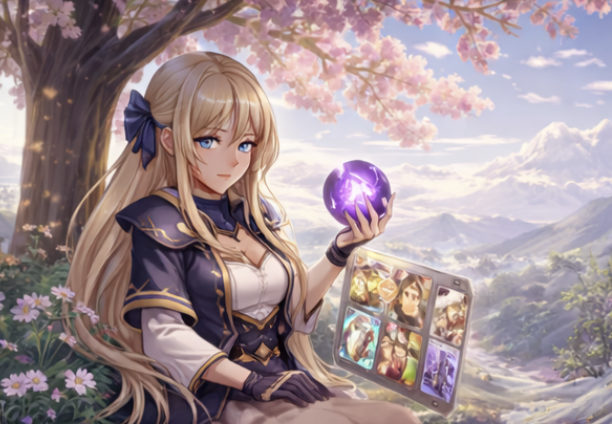


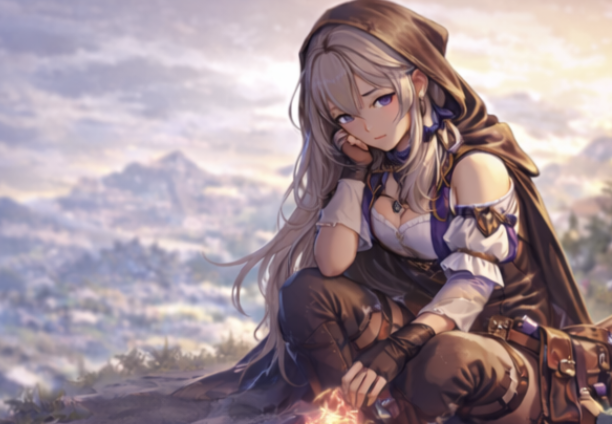


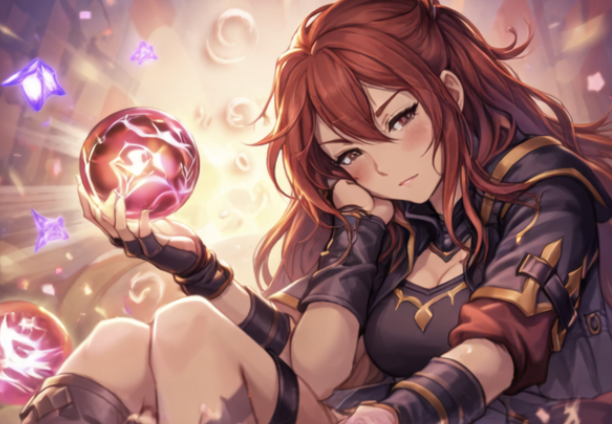


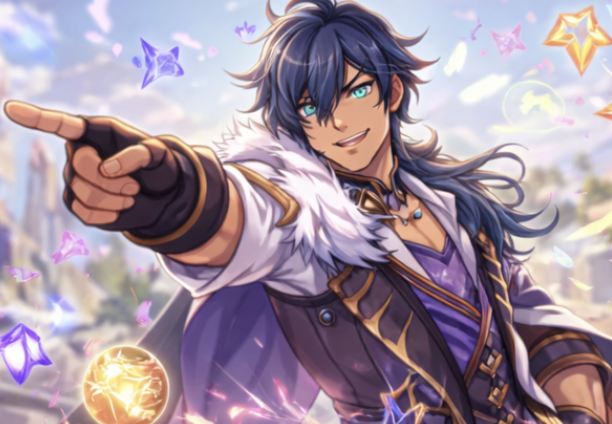

In [200]:
card_img_dir = Path("/Users/sarawahada/Downloads/artifacts/characters/")
for _, row in cross_view_cards.iterrows():
    render_cross_view_card(row, card_img_dir)

### NBA

In [201]:
nba_rules = pd.DataFrame([
    {
        "survey_segment": "Stable Light Engagers",
        "objective": "Maintain engagement",
        "message_tone": "Light, positive, non-intrusive",
        "recommended_action": "Send occasional content highlights or character/event previews",
        "contact_pressure": "Low",
        "risk_level": "Low"
    },
    {
        "survey_segment": "Quiet Break Risks",
        "objective": "Prevent silent disengagement",
        "message_tone": "Gentle, reassuring, low-pressure",
        "recommended_action": "Send soft comeback prompts tied to major updates or quality-of-life improvements",
        "contact_pressure": "Low to medium",
        "risk_level": "Moderate"
    },
    {
        "survey_segment": "Fatigued Spenders",
        "objective": "Reduce burnout while preserving attachment",
        "message_tone": "Supportive, non-exploitative, fatigue-aware",
        "recommended_action": "Highlight new content, meaningful rewards, or friction-reduction changes rather than monetization pushes",
        "contact_pressure": "Medium",
        "risk_level": "Moderate to high"
    },
    {
        "survey_segment": "Committed Enthusiasts",
        "objective": "Sustain enthusiasm",
        "message_tone": "Excited, community-oriented, value-rich",
        "recommended_action": "Share previews, lore, roadmap, and premium community-style updates",
        "contact_pressure": "Medium",
        "risk_level": "Low"
    },
    {
        "survey_segment": "Detached High-Risk Players",
        "objective": "Recover motivation without overload",
        "message_tone": "Minimal, respectful, high-signal only",
        "recommended_action": "Use rare comeback outreach focused on major improvements, simplified return paths, or meaningful catch-up value",
        "contact_pressure": "Very low",
        "risk_level": "High"
    },
    {
        "survey_segment": "Engaged but Cautious Players",
        "objective": "Protect motivation and avoid fatigue drift",
        "message_tone": "Targeted, relevant, selective",
        "recommended_action": "Send personalized updates matched to interests, but avoid excessive frequency or aggressive monetization framing",
        "contact_pressure": "Low to medium",
        "risk_level": "Moderate"
    }
])

nba_rules

,survey_segment,objective,message_tone,recommended_action,contact_pressure,risk_level
0,Stable Light Engagers,Maintain engagement,"Light, positive, non-intrusive",Send occasional content highlights or characte...,Low,Low
1,Quiet Break Risks,Prevent silent disengagement,"Gentle, reassuring, low-pressure",Send soft comeback prompts tied to major updat...,Low to medium,Moderate
2,Fatigued Spenders,Reduce burnout while preserving attachment,"Supportive, non-exploitative, fatigue-aware","Highlight new content, meaningful rewards, or ...",Medium,Moderate to high
3,Committed Enthusiasts,Sustain enthusiasm,"Excited, community-oriented, value-rich","Share previews, lore, roadmap, and premium com...",Medium,Low
4,Detached High-Risk Players,Recover motivation without overload,"Minimal, respectful, high-signal only",Use rare comeback outreach focused on major im...,Very low,High
5,Engaged but Cautious Players,Protect motivation and avoid fatigue drift,"Targeted, relevant, selective",Send personalized updates matched to interests...,Low to medium,Moderate


In [202]:
survey_nba_pref = survey_model.groupby("seg_survey_name").agg(
    top_message_type=("helpful_message_type", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    top_channel=("preferred_channel", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    top_frequency=("acceptable_msg_frequency", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    avg_break_likelihood=("break_likelihood_num", "mean"),
    avg_motivation=("motivation_score_num", "mean"),
    avg_disengagement_risk=("survey_disengagement_risk", "mean")
).round(3).reset_index()

survey_nba_pref

,seg_survey_name,top_message_type,top_channel,top_frequency,avg_break_likelihood,avg_motivation,avg_disengagement_risk
0,Committed Enthusiasts,A reward / incentive-based message,Email,2–3 times a month,1.600,9.400,2.067
1,Detached High-Risk Players,A reward / incentive-based message,In-game notification,About once a week,4.750,4.000,4.750
2,Engaged but Cautious Players,A reward / incentive-based message,In-game notification,About once a week,2.200,7.600,2.267
3,Fatigued Spenders,A reward / incentive-based message,In-game notification,2–3 times a month,2.500,5.100,2.133
4,Quiet Break Risks,Personalized recommendations (characters/build...,In-game notification,Never (I do not want outreach),3.500,6.667,3.167
5,Stable Light Engagers,A short reminder of what’s new,In-game notification,2–3 times a month,2.429,8.143,1.619


In [203]:
final_nba_table = survey_nba_pref.merge(
    nba_rules,
    left_on="seg_survey_name",
    right_on="survey_segment",
    how="left"
)

final_nba_table

,seg_survey_name,top_message_type,top_channel,top_frequency,avg_break_likelihood,avg_motivation,avg_disengagement_risk,survey_segment,objective,message_tone,recommended_action,contact_pressure,risk_level
0,Committed Enthusiasts,A reward / incentive-based message,Email,2–3 times a month,1.600,9.400,2.067,Committed Enthusiasts,Sustain enthusiasm,"Excited, community-oriented, value-rich","Share previews, lore, roadmap, and premium com...",Medium,Low
1,Detached High-Risk Players,A reward / incentive-based message,In-game notification,About once a week,4.750,4.000,4.750,Detached High-Risk Players,Recover motivation without overload,"Minimal, respectful, high-signal only",Use rare comeback outreach focused on major im...,Very low,High
2,Engaged but Cautious Players,A reward / incentive-based message,In-game notification,About once a week,2.200,7.600,2.267,Engaged but Cautious Players,Protect motivation and avoid fatigue drift,"Targeted, relevant, selective",Send personalized updates matched to interests...,Low to medium,Moderate
3,Fatigued Spenders,A reward / incentive-based message,In-game notification,2–3 times a month,2.500,5.100,2.133,Fatigued Spenders,Reduce burnout while preserving attachment,"Supportive, non-exploitative, fatigue-aware","Highlight new content, meaningful rewards, or ...",Medium,Moderate to high
4,Quiet Break Risks,Personalized recommendations (characters/build...,In-game notification,Never (I do not want outreach),3.500,6.667,3.167,Quiet Break Risks,Prevent silent disengagement,"Gentle, reassuring, low-pressure",Send soft comeback prompts tied to major updat...,Low to medium,Moderate
5,Stable Light Engagers,A short reminder of what’s new,In-game notification,2–3 times a month,2.429,8.143,1.619,Stable Light Engagers,Maintain engagement,"Light, positive, non-intrusive",Send occasional content highlights or characte...,Low,Low


In [204]:
action_family_map = {
    "Stable Light Engagers": "Maintain",
    "Quiet Break Risks": "Nudge",
    "Fatigued Spenders": "Reassure",
    "Committed Enthusiasts": "Maintain",
    "Detached High-Risk Players": "Reignite",
    "Engaged but Cautious Players": "Protect",
}

final_nba_table["action_family"] = final_nba_table["seg_survey_name"].map(action_family_map)
final_nba_table

,seg_survey_name,top_message_type,top_channel,top_frequency,avg_break_likelihood,avg_motivation,avg_disengagement_risk,survey_segment,objective,message_tone,recommended_action,contact_pressure,risk_level,action_family
0,Committed Enthusiasts,A reward / incentive-based message,Email,2–3 times a month,1.600,9.400,2.067,Committed Enthusiasts,Sustain enthusiasm,"Excited, community-oriented, value-rich","Share previews, lore, roadmap, and premium com...",Medium,Low,Maintain
1,Detached High-Risk Players,A reward / incentive-based message,In-game notification,About once a week,4.750,4.000,4.750,Detached High-Risk Players,Recover motivation without overload,"Minimal, respectful, high-signal only",Use rare comeback outreach focused on major im...,Very low,High,Reignite
2,Engaged but Cautious Players,A reward / incentive-based message,In-game notification,About once a week,2.200,7.600,2.267,Engaged but Cautious Players,Protect motivation and avoid fatigue drift,"Targeted, relevant, selective",Send personalized updates matched to interests...,Low to medium,Moderate,Protect
3,Fatigued Spenders,A reward / incentive-based message,In-game notification,2–3 times a month,2.500,5.100,2.133,Fatigued Spenders,Reduce burnout while preserving attachment,"Supportive, non-exploitative, fatigue-aware","Highlight new content, meaningful rewards, or ...",Medium,Moderate to high,Reassure
4,Quiet Break Risks,Personalized recommendations (characters/build...,In-game notification,Never (I do not want outreach),3.500,6.667,3.167,Quiet Break Risks,Prevent silent disengagement,"Gentle, reassuring, low-pressure",Send soft comeback prompts tied to major updat...,Low to medium,Moderate,Nudge
5,Stable Light Engagers,A short reminder of what’s new,In-game notification,2–3 times a month,2.429,8.143,1.619,Stable Light Engagers,Maintain engagement,"Light, positive, non-intrusive",Send occasional content highlights or characte...,Low,Low,Maintain


### Next-Best-Action Layer

The NBA layer is the project’s most operational output. It converts survey-defined motivation and risk profiles into more appropriate communication strategies. For example, **Committed Enthusiasts** can tolerate richer value-oriented updates, whereas **Detached High-Risk Players** should receive minimal, high-signal, low-pressure outreach. This demonstrates how the analytical framework can support deployment-oriented decisions without requiring a live production recommender.

### Deployment Summary

The final deployment output of the project is a prototype **player-intelligence framework** rather than a production model. Its main deployable assets are segment profile tables, cross-view correspondence logic, preference summaries, and a survey-informed NBA layer. Together, these outputs translate the project’s analytical findings into a practical structure for player-risk interpretation, communication design, and future retention strategy development.